# Predicción de Producción de Petróleo no convencional en Vaca Muerta con Transformers

## 1. Introducción

Este notebook entrena y evalúa un `ARTransformerForecaster` para predecir la producción mensual de petróleo (`prod_pet`, 12 meses de horizonte) de pozos no convencionales de Vaca Muerta, usando el pipeline de datos de `datasets.py` (`PozoDataModule`/`PozoWindowDataset`), desarrollado y testeado de forma aislada en `preparacion.ipynb`/`test_datasets.ipynb`.

Estructura de la notebook:
- **Sección 1.1 — Manejo de ventanas y predicciones**: cómo se arman las ventanas de entrada/target (train desliza, val/test quedan fijas por calendario), y el soporte de `PozoDataModule` para evaluar generalización a pozos vistos/no vistos.
- **Sección 2 — Setup**: imports y semilla fija, para que las corridas sean reproducibles.
- **Sección 3 — Funciones de utilidad**: métricas (MAPE, R², MAPE robusto) y el objeto `ResultadoEvaluacion` que las agrupa, compartidos por todas las ejecuciones.
- **Sección 4 — Definición del modelo**: arquitectura `ARTransformerForecaster`, y el helper `entrenar_y_evaluar_config` (Sección 4.1) que entrena y evalúa una configuración en un solo llamado.
- **Sección 5 — Utilidades de visualización**: funciones para graficar predicción vs. real por pozo.
- **Sección 6 — Ejecución A**: modelo entrenado con el dataset completo (incluye pozos con paradas).
- **Sección 7 — Ejecución B**: modelo entrenado minimizando pozos con paradas, para dimensionar cuánto del error se explica por esas paradas impredecibles. Incluye el ajuste de hiperparámetros (Sección 7.6) y visualizaciones de mejores y peores predicciones
- **Sección 8 — Comparación y conclusiones**: resultados de todas las configuraciones evaluadas, y las Conclusiones (8.3) que cierran el TP.
- **Sección 9 — Ideas para el trabajo final de la maestría**: líneas surgidas de este TP para retomar en el TF.



### 1.1 Manejo de ventanas y predicciones

#### Armado de ventanas

El modelo predice `prod_pet` a 12 meses (`target`) a partir de los 36 meses previos (`input`). Train y Val/Test arman esas ventanas de forma distinta:

- **Train**: ventanas *deslizantes* -- para cada pozo elegible, se generan todas las ventanas posibles corriendo el inicio 1 mes a la vez, desde el propio inicio de historia del pozo hasta el último punto que deja lugar a un target completo. Un pozo con mucha historia aporta muchas ventanas; uno con la historia mínima aporta exactamente `MIN_VENTANAS_TRAIN` (12 con los defaults).
- **Val y Test**: una **única ventana fija por calendario**, igual para todos los pozos elegibles -- no se desliza. Val evalúa siempre el mismo tramo de 12 meses, y Test el tramo de 12 meses más reciente del dataset. Esto es clave para que la comparación entre pozos (y entre corridas) sea sobre el mismo período, no sobre períodos distintos según cuánta historia tenga cada uno.

Ejemplo ilustrativo (con los defaults `INPUT_LEN=36`, `TARGET_LEN=12`, `MIN_VENTANAS_TRAIN=12`, ver `calcular_cortes_split` en `datasets.py`):

| Ventana | Split | Input (36 meses) | Target (12 meses) |
|---|---|---|---|
| 1 | Train | 2019-07 → 2022-06 | 2022-07 → 2023-06 |
| 2 | Train | 2019-08 → 2022-07 | 2022-08 → 2023-07 |
| ... | Train | ... | ... |
| 12 | Train | 2020-06 → 2023-05 | 2023-06 → 2024-05 |
| — | **Val** (fija) | 2021-06 → 2024-05 | 2024-06 → 2025-05 |
| — | **Test** (fija) | 2022-06 → 2025-05 | 2025-06 → 2026-05 |

Observar que el target de Train nunca se superpone con el de Val, ni el de Val con el de Test -- son tramos de calendario consecutivos y excluyentes, así ningún mes usado para evaluar fue visto como target durante el entrenamiento.

#### Capacidad de generalización a pozos no vistos

Este esquema de cortes permite separar, dentro de Val y Test, los pozos que el modelo **sí vio** durante el entrenamiento (aportaron alguna ventana a Train) de los que **nunca vio** -- y evaluar por separado qué tan bien predice en cada grupo. Esa distinción es la de generalización *cross-series*: además de "¿el modelo interpola bien dentro de series que ya conoce?",   "¿el modelo puede predecir la producción de un pozo completamente nuevo, usando solo lo que aprendió de otros pozos similares?" 

#### Soporte en `PozoDataModule`: seen / unseen

`PozoDataModule.setup()` arma 5 datasets, no 3: `ds_train`, `ds_val_seen`, `ds_val_unseen`, `ds_test_seen`, `ds_test_unseen`. "Vistos" (`seen`) son los pozos que efectivamente aportaron alguna ventana a `ds_train`; el resto son `unseen`. `val_dataloader()`/`test_dataloader()` (los hooks estándar que usa el `Trainer` de PyTorch Lightning) apuntan solo a los pozos vistos -- es la señal correcta para dirigir entrenamiento/early stopping/checkpointing. `val_dataloader_unseen()`/`test_dataloader_unseen()` son métodos aparte, que el `Trainer` no invoca solo, pensados para evaluar a mano la capacidad de generalización a pozos nuevos cuando se decida medirla.

**Nota**: en esta notebook, las Secciones 6 y 7 evalúan únicamente sobre `val_seen` -- la comparación de desempeño en pozos `unseen` está soportada por el pipeline pero todavía no se ejecutó (queda como uno de los próximos pasos, Sección 9).


## 2. Setup

In [21]:
# Configurar el entorno y ejecutar como se indica en readme.txt

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

# Set plotting style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

SEED = 42  # fija la inicialización de pesos y el shuffle del DataLoader de train, para que las corridas sean reproducibles y comparables entre configuraciones de hiperparámetros.
pl.seed_everything(SEED, workers=True)

Seed set to 42


42

## 3. Funciones de utilidad

Métricas usadas para evaluar el modelo en unidades reales (m³), compartidas entre las Ejecuciones A y B.

In [23]:
# Define MAPE function (not directly available in sklearn)
def mean_absolute_percentage_error(y_true, y_pred):
    """
    Calculate Mean Absolute Percentage Error (MAPE)

    Args:
        y_true: Actual values
        y_pred: Predicted values

    Returns:
        MAPE value
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [24]:
def r2_score_manual(y_true, y_pred):
    """R² = 1 - SS_res/SS_tot (implementado a mano, sin depender de sklearn)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

In [25]:
from dataclasses import dataclass
from typing import Optional

from datasets import desnormalizar_prod_pet


@dataclass
class ResultadoEvaluacion:
    """Resume una corrida de evaluación (`evaluar_mape_r2`), para comparar configuraciones sin recalcular nada."""
    y_true_reales: np.ndarray
    y_pred_reales: np.ndarray
    n: int
    mape: float
    r2: float
    mape_robusto: float
    meses_excluidos: int
    nombre_config: Optional[str] = None

    def __str__(self):
        return (
            f"[{self.nombre_config}]\n"
            f"  n               = {self.n:,}\n"
            f"  MAPE            = {self.mape:.2f}%\n"
            f"  R²              = {self.r2:.4f}\n"
            f"  MAPE robusto    = {self.mape_robusto:.2f}%\n"
            f"  Meses excluidos = {self.meses_excluidos} de {self.n}"
        )

    def __repr__(self):
        # Compacto a propósito: el __repr__ que generaría @dataclass por
        # default incluye y_true_reales/y_pred_reales completos (arrays
        # grandes), poco legible si el objeto se muestra sin `print` (ej.
        # como última línea de una celda, o dentro de una lista/dict).
        return (
            f"ResultadoEvaluacion(nombre_config={self.nombre_config!r}, n={self.n}, "
            f"mape={self.mape:.2f}, r2={self.r2:.4f}, mape_robusto={self.mape_robusto:.2f})"
        )


def evaluar_mape_r2(model, dataloader, normalizacion):
    """
    Corre el modelo en modo evaluación (inferencia autoregresiva real,
    self.training=False) sobre `dataloader`, des-normaliza predicciones y
    target a m³ reales (media_log/std_log por pozo) y devuelve un
    `ResultadoEvaluacion` con las métricas sobre el conjunto completo
    (todos los pozos, los 12 meses del horizonte).
    """
    model.eval()
    device = next(model.parameters()).device

    y_true_reales, y_pred_reales = [], []

    with torch.no_grad():
        for batch in dataloader:
            x_prod_pet = batch["x_prod_pet"].to(device)
            x_regressors = batch["x_regressors"].to(device)
            y_regressors = batch["y_regressors"].to(device)
            y_prod_pet = batch["y_prod_pet"].to(device)
            idpozo = batch["idpozo"]

            y_hat = model(x_prod_pet, x_regressors, y_regressors)

            for i, pozo in enumerate(idpozo.tolist()):
                media_log, std_log = normalizacion.loc[pozo, ["media_log", "std_log"]]
                y_true_reales.append(desnormalizar_prod_pet(y_prod_pet[i].cpu().numpy().ravel(), media_log, std_log))
                y_pred_reales.append(desnormalizar_prod_pet(y_hat[i].cpu().numpy().ravel(), media_log, std_log))

    y_true_reales = np.concatenate(y_true_reales)
    y_pred_reales = np.concatenate(y_pred_reales)

    valor_mape_robusto = mape_robusto(y_true_reales, y_pred_reales)

    resultado = ResultadoEvaluacion(
        y_true_reales=y_true_reales,
        y_pred_reales=y_pred_reales,
        n=len(y_true_reales),
        mape=mean_absolute_percentage_error(y_true_reales, y_pred_reales),
        r2=r2_score_manual(y_true_reales, y_pred_reales),
        mape_robusto=valor_mape_robusto,
        meses_excluidos=int((np.abs(y_true_reales) <= 1).sum()),
    )

    print(f"n = {resultado.n:,} valores (pozo-mes)")
    print(f"MAPE: {resultado.mape:.2f}%")
    print(f"R²  : {resultado.r2:.4f}")
    print(f"MAPE robusto (umbral=1 m³): {resultado.mape_robusto:.2f}%  (excluye {resultado.meses_excluidos} de {resultado.n} meses casi-nulos)")

    return resultado

In [26]:
def mape_robusto(y_true, y_pred, umbral=1.0):
    """
    MAPE con un piso mínimo en el denominador (en vez de excluir solo
    y_true == 0 exacto). Necesario acá porque los "ceros" de meses de
    parada, después de la ida y vuelta por log1p/z-score/expm1, no vuelven
    a dar exactamente 0.0 (quedan en el orden de 1e-9 por redondeo de
    float32) -- el filtro original no los excluye, y dividir por un número
    así de chico infla el promedio a valores sin sentido.
    `umbral` en las mismas unidades que y_true (m³) -- 1.0 excluye meses de
    producción prácticamente nula, con la misma intención que el filtro
    original de excluir los ceros.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = np.abs(y_true) > umbral
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [27]:
import glob
import re


def _val_loss_de_archivo(ruta):
    """Extrae el val_loss del nombre de archivo de un checkpoint (ej.
    'lstm-epoch=01-val_loss=1.95.ckpt') -- usado en las Secciones 6.3 y 7.4
    para elegir el checkpoint de menor val_loss."""
    match = re.search(r"val_loss=([\d.]+)(?:-v\d+)?\.ckpt$", ruta)
    return float(match.group(1))



## 4. Definición del modelo

`ARTransformerForecaster`: Transformer autoregresivo (encoder-decoder). Entrena con teacher forcing (ver el método `forward`): en cada paso del decoder usa como input el valor real del mes anterior, no la propia predicción. Al evaluar/inferir corre en modo autoregresivo real: se alimenta de sus propias predicciones. 

In [28]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import pytorch_lightning as pl
import math
from typing import Optional, Dict, Any

class PositionalEncoding(nn.Module):
    """
    Standard sinusoidal positional encoding for the encoder.
    """
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)  # [max_len, 1]
        div_term = torch.exp(torch.arange(0, d_model, 2) *
                             (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)  # [max_len, d_model]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, seq_len, d_model]
        seq_len = x.size(1)
        x = x + self.pe[:seq_len].unsqueeze(0)
        return self.dropout(x)

class BaseForecaster(pl.LightningModule):
    """
    Simplified LightningModule for forecasting that
    ARTransformerForecaster will extend.
    """
    def __init__(self, learning_rate: float = 1e-3):
        super().__init__()
        self.learning_rate = learning_rate

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)

class ARTransformerForecaster(BaseForecaster):
    """
    Autoregressive Transformer for univariate forecasting,
    with teacher-forcing during training and proper positional
    encoding. Uses history and future regressors.
    """
    def __init__(
        self,
        input_dim: int,
        regressor_dim: int,
        hidden_dim: int = 64,
        output_dim: int = 1,
        forecast_length: int = 12,
        num_layers: int = 2,
        nhead: int = 4,
        dropout: float = 0.1,
        learning_rate: float = 1e-3,
    ):
        super().__init__(learning_rate)
        self.save_hyperparameters()

        self.input_dim = input_dim
        self.regressor_dim = regressor_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.forecast_length = forecast_length

        # Encoder: [demand + history_regressors] → hidden_dim
        enc_input_dim = input_dim + regressor_dim
        self.input_projection = nn.Linear(enc_input_dim, hidden_dim)

        # Decoder: [previous_output + future_regressors] → hidden_dim
        dec_input_dim = output_dim + regressor_dim
        self.decoder_input_projection = nn.Linear(dec_input_dim, hidden_dim)

        # Encoder & decoder
        enc_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=nhead, dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        dec_layer = nn.TransformerDecoderLayer(
            d_model=hidden_dim, nhead=nhead, dropout=dropout, batch_first=True
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_layers)

        # Positional encodings
        self.pos_encoder = PositionalEncoding(hidden_dim, dropout)
        self.decoder_pos_embedding = nn.Embedding(forecast_length, hidden_dim)

        # Output projection
        self.output_projection = nn.Linear(hidden_dim, output_dim)

    def generate_square_subsequent_mask(self, sz: int, device: torch.device) -> torch.Tensor:
        return torch.triu(
            torch.full((sz, sz), float('-inf'), device=device),
            diagonal=1
        )

    def forward(
        self,
        x_prod_pet: torch.Tensor,         # [B, hist_len, input_dim]
        x_regressor: Optional[torch.Tensor],  # [B, hist_len, regressor_dim]
        y_regressor: torch.Tensor,      # [B, forecast_length, regressor_dim]
        y_prod_pet: Optional[torch.Tensor] = None # [B, forecast_length, output_dim]
    ) -> torch.Tensor:
        B, hist_len, _ = x_prod_pet.shape
        device = x_prod_pet.device

        # 1) Encoder
        if x_regressor is None:
            x_regressor = torch.zeros(B, hist_len, self.regressor_dim, device=device)
        enc_input = torch.cat([x_prod_pet, x_regressor], dim=-1)
        enc_proj = self.input_projection(enc_input)
        enc_pos = self.pos_encoder(enc_proj)
        memory = self.encoder(enc_pos)

        
        # 2) Training with teacher forcing
        if self.training and y_prod_pet is not None:
            # prepend last history demand
            last_hist = x_prod_pet[:, -1:, :]
            if self.input_dim != self.output_dim:
                last_hist = last_hist[..., :self.output_dim]
            y_shift = torch.cat([last_hist, y_prod_pet[:, :-1, :]], dim=1)
            dec_input = torch.cat([y_shift, y_regressor], dim=-1)
            dec_proj = self.decoder_input_projection(dec_input)

            pos_idxs = torch.arange(self.forecast_length, device=device).unsqueeze(0)
            pos_emb = self.decoder_pos_embedding(pos_idxs)
            dec_proj = dec_proj + pos_emb

            tgt_mask = self.generate_square_subsequent_mask(self.forecast_length, device)
            dec_out = self.decoder(dec_proj, memory, tgt_mask=tgt_mask)
            return self.output_projection(dec_out)
    
            
        # 3) Inference
        preds = []
        last_hist = x_prod_pet[:, -1:, :]
        if self.input_dim != self.output_dim:
            last_hist = last_hist[..., :self.output_dim]
        prev = torch.cat([last_hist, y_regressor[:, :1, :]], dim=-1)
        prev_hidden = self.decoder_input_projection(prev)

        for t in range(self.forecast_length):
            pos_emb_t = self.decoder_pos_embedding(
                torch.full((B, 1), t, device=device, dtype=torch.long)
            )
            dec_in = prev_hidden + pos_emb_t
            dec_out = self.decoder(dec_in, memory)
            y_t = self.output_projection(dec_out)
            preds.append(y_t)

            if t + 1 < self.forecast_length:
                next_reg = y_regressor[:, t+1:t+2, :]
                nxt = torch.cat([y_t, next_reg], dim=-1)
                prev_hidden = self.decoder_input_projection(nxt)

        return torch.cat(preds, dim=1)

    def training_step(self, batch: Dict[str, torch.Tensor], batch_idx: int):
        x = batch['x_prod_pet']
        x_reg = batch.get('x_regressors', None)
        y_reg = batch['y_regressors']
        y = batch['y_prod_pet']
        y_hat = self(x, x_reg, y_reg, y)
        loss = F.mse_loss(y_hat, y)
        mae  = F.l1_loss(y_hat, y)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_mae', mae, prog_bar=True)
        return loss

    def validation_step(self, batch: Dict[str, torch.Tensor], batch_idx: int):
        x = batch['x_prod_pet']
        x_reg = batch.get('x_regressors', None)
        y_reg = batch['y_regressors']
        y = batch['y_prod_pet']
        y_hat = self(x, x_reg, y_reg, y)
        loss = F.mse_loss(y_hat, y)
        mae  = F.l1_loss(y_hat, y)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_mae', mae, prog_bar=True)

    def test_step(self, batch: Dict[str, torch.Tensor], batch_idx: int):
        x = batch['x_prod_pet']
        x_reg = batch.get('x_regressors', None)
        y_reg = batch['y_regressors']
        y = batch['y_prod_pet']
        y_hat = self(x, x_reg, y_reg, y)
        loss = F.mse_loss(y_hat, y)
        mae  = F.l1_loss(y_hat, y)
        self.log('test_loss', loss)
        self.log('test_mae', mae)

### 4.1 Entrenamiento y evaluación de una configuración

`entrenar_y_evaluar_config` encapsula el patrón repetido entre las Secciones 6 y 7 (armar `Trainer` con checkpointing/early stopping, entrenar, cargar el mejor checkpoint por `val_loss`, evaluar con `evaluar_mape_r2`). Se usa para no duplicar código entre la Ejecución A, la Ejecución B y las distintas configuraciones de hiperparámetros de la Sección 7.

In [29]:
from pytorch_lightning.loggers import CSVLogger


def entrenar_y_evaluar_config(
    data_module,
    nombre_config,
    dirpath_checkpoints,
    nombre_logs,
    entrenar=True,
    max_epochs=20,
    patience=10,
    **kwargs_modelo,
):
    """
    Entrena (o reusa el checkpoint ya guardado) y evalúa una configuración
    del modelo sobre `data_module`. `kwargs_modelo` son los hiperparámetros
    que varían por configuración (hidden_dim, learning_rate, num_layers,
    nhead, dropout, ...) -- input_dim/regressor_dim/output_dim/
    forecast_length se toman siempre de `data_module`.

    Selección del checkpoint a evaluar (siempre se recarga el modelo desde
    disco, nunca se reusan los pesos en memoria post-entrenamiento -- por
    `patience`, la última época entrenada no es necesariamente la mejor):
    - `entrenar=True`: se usa `checkpoint_callback.best_model_path`, la RUTA
      (no los pesos) al mejor checkpoint de ESTA corrida, trackeada en
      memoria por PyTorch Lightning durante el entrenamiento -- no se
      mezcla con archivos de corridas anteriores que puedan seguir en
      `dirpath_checkpoints`.
    - `entrenar=False`: no hay `Trainer` vivo que exponga esa ruta, así que
      se busca en `dirpath_checkpoints` el archivo con menor val_loss según
      su nombre (`_val_loss_de_archivo`). Asume que ese directorio contiene
      solo checkpoints de la corrida que se quiere reusar.

    Devuelve (model, resultado), con resultado: ResultadoEvaluacion (Sección 3).
    """
    checkpoint_callback = ModelCheckpoint(
        monitor="val_loss",
        dirpath=dirpath_checkpoints,
        filename="lstm-{epoch:02d}-{val_loss:.2f}",
        save_top_k=3,
        mode="min",
    )
    early_stop_callback = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        verbose=True,
        mode="min",
    )
    trainer = pl.Trainer(
        max_epochs=max_epochs,
        callbacks=[checkpoint_callback, early_stop_callback],
        log_every_n_steps=10,
        enable_progress_bar=True,
        logger=CSVLogger(save_dir=".", name=nombre_logs),
    )

    model = ARTransformerForecaster(
        input_dim=data_module.get_input_dim(),
        regressor_dim=data_module.get_regressor_dim(),
        output_dim=data_module.get_output_dim(),
        forecast_length=data_module.get_forecast_length(),
        **kwargs_modelo,
    )

    if entrenar:
        print(f"=== {nombre_config}: entrenando ===")
        trainer.fit(model, data_module)
        test_results = trainer.test(model, data_module)
        print(f"Test results: {test_results}")
        mejor_checkpoint = checkpoint_callback.best_model_path
    else:
        print(f"=== {nombre_config}: entrenar=False -> se reusa el mejor checkpoint en {dirpath_checkpoints} ===")
        checkpoints = glob.glob(f"{dirpath_checkpoints}/*.ckpt")
        mejor_checkpoint = min(checkpoints, key=_val_loss_de_archivo)

    print(f"Cargando checkpoint: {mejor_checkpoint}")

    model = ARTransformerForecaster.load_from_checkpoint(mejor_checkpoint, map_location="cpu")
    model.eval()

    print(f"\n=== {nombre_config}: evaluación (val_seen) ===")
    resultado = evaluar_mape_r2(model, data_module.val_dataloader(), data_module.normalizacion)
    resultado.nombre_config = nombre_config

    return model, resultado

## 5. Utilidades de visualización

Building blocks (`obtener_prediccion_ventana`/`graficar_prediccion_pozo`/`graficar_pozos`) y selectores de pozos por distintos criterios, compartidos entre las Ejecuciones A y B.

In [30]:
import pandas as pd

from datasets import PozoWindowDataset


def obtener_prediccion_ventana(model, dataset, idx, normalizacion):
    """
    Corre el modelo sobre UNA ventana puntual (índice `idx` de `dataset`) y
    devuelve un dict con las series en unidades reales (m³) y sus períodos
    calendario, listo para graficar: input histórico, target real, target
    predicho, y metadata (idpozo, tipoestado).
    """
    model.eval()
    device = next(model.parameters()).device

    ejemplo = dataset[idx]
    idpozo = int(ejemplo["idpozo"])
    media_log, std_log = normalizacion.loc[idpozo, ["media_log", "std_log"]]

    x_prod_pet = ejemplo["x_prod_pet"].unsqueeze(0).to(device)
    x_regressors = ejemplo["x_regressors"].unsqueeze(0).to(device)
    y_regressors = ejemplo["y_regressors"].unsqueeze(0).to(device)

    with torch.no_grad():
        y_hat = model(x_prod_pet, x_regressors, y_regressors)

    return {
        "idpozo": idpozo,
        "input_periodos": ejemplo["input_periodos"],
        "x_prod_pet_real": desnormalizar_prod_pet(ejemplo["x_prod_pet"].numpy().ravel(), media_log, std_log),
        "target_periodos": ejemplo["target_periodos"],
        "y_true_real": desnormalizar_prod_pet(ejemplo["y_prod_pet"].numpy().ravel(), media_log, std_log),
        "y_pred_real": desnormalizar_prod_pet(y_hat.squeeze(0).cpu().numpy().ravel(), media_log, std_log),
        "tipoestado_target": ejemplo["tipoestado_target"],
    }


def graficar_prediccion_pozo(prediccion, ax=None):
    """
    Grafica una ventana individual: historia (36 meses) + target real vs.
    predicho (12 meses), con eje X de fechas calendario y los meses de
    parada real (tipoestado_target) marcados -- para distinguir de un
    vistazo el error "esperable" (parada, irreducible por diseño) del resto.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))

    fechas_input = pd.PeriodIndex(prediccion["input_periodos"], freq="M").to_timestamp()
    fechas_target = pd.PeriodIndex(prediccion["target_periodos"], freq="M").to_timestamp()

    ax.plot(fechas_input, prediccion["x_prod_pet_real"], color="steelblue", marker="o", markersize=3, label="Historia (input)")
    ax.plot(fechas_target, prediccion["y_true_real"], color="black", marker="o", markersize=4, label="Real (target)")
    ax.plot(fechas_target, prediccion["y_pred_real"], color="crimson", marker="x", markersize=5, linestyle="--", label="Predicho")

    # Sombreo los meses de parada real del target (activo=False) para dar contexto.
    for fecha, estado in zip(fechas_target, prediccion["tipoestado_target"]):
        if estado not in PozoWindowDataset.VALORES_TIPOESTADO_ACTIVO:
            ax.axvspan(fecha - pd.Timedelta(days=15), fecha + pd.Timedelta(days=15), color="orange", alpha=0.2)

    ax.set_title(f"Pozo {prediccion['idpozo']}")
    ax.set_ylabel("prod_pet (m³)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=45)


def graficar_pozos(model, dataset, indices, normalizacion, ncols=2):
    """Grilla de subplots, uno por índice en `indices` -- reusa
    obtener_prediccion_ventana + graficar_prediccion_pozo por cada uno."""
    n = len(indices)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows), squeeze=False)

    for ax, idx in zip(axes.ravel(), indices):
        prediccion = obtener_prediccion_ventana(model, dataset, idx, normalizacion)
        graficar_prediccion_pozo(prediccion, ax=ax)

    # Apago los ejes sobrantes si `indices` no llena toda la grilla.
    for ax in axes.ravel()[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [31]:
def seleccionar_ventanas_aleatorias(dataset, n, seed=42):
    """n índices al azar del dataset, reproducible con seed."""
    rng = np.random.default_rng(seed)
    return rng.choice(len(dataset), size=min(n, len(dataset)), replace=False).tolist()


def seleccionar_ventanas_por_produccion(dataset, normalizacion, cuartil):
    """
    Índices cuyo pozo cae en el cuartil de producción pedido (1=más bajo,
    4=más alto), según `media_log` de `normalizacion` -- para mostrar que
    el modelo no se comporta igual en pozos grandes vs. chicos.
    """
    idpozos = dataset.ventanas["idpozo"]
    media_log_por_ventana = normalizacion.loc[idpozos, "media_log"].to_numpy()
    limites = np.quantile(media_log_por_ventana, [0, 0.25, 0.5, 0.75, 1.0])
    lo, hi = limites[cuartil - 1], limites[cuartil]
    en_cuartil = (media_log_por_ventana >= lo) & (media_log_por_ventana <= hi)
    return np.flatnonzero(en_cuartil).tolist()


def seleccionar_ventanas_con_parada(dataset, con_parada=True):
    """
    Índices cuyo tipoestado_target tiene (o no tiene, según `con_parada`) al
    menos un mes fuera de VALORES_TIPOESTADO_ACTIVO -- separa casos
    "limpios" de casos con parada real en el horizonte.
    """
    indices = []
    for i in range(len(dataset)):
        estados = dataset[i]["tipoestado_target"]
        tiene_parada = any(e not in PozoWindowDataset.VALORES_TIPOESTADO_ACTIVO for e in estados)
        if tiene_parada == con_parada:
            indices.append(i)
    return indices


def seleccionar_ventanas_por_error(model, dataset, normalizacion, top_n, peor=True):
    """
    Corre el modelo sobre todo `dataset`, calcula el MAPE robusto por
    ventana, y devuelve los `top_n` índices con mayor (peor=True) o menor
    error -- para mostrar el mejor y el peor caso concreto. Pensada para
    datasets chicos (val/test), no para train.
    """
    errores = []
    for i in range(len(dataset)):
        pred = obtener_prediccion_ventana(model, dataset, i, normalizacion)
        errores.append(mape_robusto(pred["y_true_real"], pred["y_pred_real"]))
    errores = np.array(errores)
    orden = np.argsort(errores)
    seleccionados = orden[::-1][:top_n] if peor else orden[:top_n]
    return seleccionados.tolist()

## 6. Ejecución A — modelo con paradas

Modelo entrenado sobre el dataset completo, incluyendo pozos con paradas administrativas/operativas durante el horizonte de predicción.

### 6.1 Pipeline de datos

In [32]:
from datasets import PozoDataModule, INPUT_LEN, TARGET_LEN, MIN_VENTANAS_TRAIN

data_module = PozoDataModule(
    ruta_datos="datos_modelo.csv",
    batch_size=32,
    input_len=INPUT_LEN,
    target_len=TARGET_LEN,
    min_ventanas_train=MIN_VENTANAS_TRAIN,
)
data_module.setup()

### 6.2 Entrenamiento

In [33]:
ENTRENAR = True  # poner en False para saltear el entrenamiento y reusar el checkpoint ya guardado en checkpoints/ -- más práctico para iterar sobre el resto de la notebook.

model, resultado = entrenar_y_evaluar_config(
    data_module,
    nombre_config="Ejecución A",
    dirpath_checkpoints="./checkpoints/",
    nombre_logs="lightning_logs",
    entrenar=ENTRENAR,
    hidden_dim=64,
    num_layers=2,
    nhead=4,
    dropout=0.1,
    learning_rate=1e-3,
)
print(resultado)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== Ejecución A: entrenando ===


c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\ignsagul\OneDrive - Publicis Groupe\MMA\14_Deep Learning\tp-final\checkpoints exists and is not empty.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ input_projection         │ Linear             │    832 │ train │     0 │
│ 1 │ decoder_input_projection │ Linear             │    832 │ train │     0 │
│ 2 │ encoder                  │ TransformerEncoder │  562 K │ train │     0 │
│ 3 │ decoder                  │ TransformerDecoder │  595 K │ train │     0 │
│ 4 │ pos_encoder              │ PositionalEncoding │      0 │ train │     0 │
│ 5 │ decoder_pos_embedding    │ Embedding          │    768 │ train │     0 │
│ 6 │ output_projection        │ Linear             │     65 │ train │     0 │
└───┴──────────────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 1.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.2 M                                                                                                
Total estimated model params size (MB): 4.643                                                                      
Modules in train mode: 58                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │     2.285543918609619     │
│         test_mae          │     1.167795181274414     │
└───────────────────────────┴───────────────────────────┘

Test results: [{'test_loss': 2.285543918609619, 'test_mae': 1.167795181274414}]
Cargando checkpoint: C:\Users\ignsagul\OneDrive - Publicis Groupe\MMA\14_Deep Learning\tp-final\checkpoints\lstm-epoch=00-val_loss=1.77-v1.ckpt

=== Ejecución A: evaluación (val_seen) ===


c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


n = 2,460 valores (pozo-mes)
MAPE: 35368526821.44%
R²  : 0.0367
MAPE robusto (umbral=1 m³): 163.73%  (excluye 469 de 2460 meses casi-nulos)
[Ejecución A]
  n               = 2,460
  MAPE            = 35368526821.44%
  R²              = 0.0367
  MAPE robusto    = 163.73%
  Meses excluidos = 469 de 2460


### 6.3 Resultados

La carga del mejor checkpoint y la evaluación (`evaluar_mape_r2` sobre `val_seen`) ya ocurrieron dentro de `entrenar_y_evaluar_config`, en la Sección 6.2. El resultado de la Ejecución A, que se ve un poco más arriba, queda guardado en un objeto `ResultadoEvaluacion`  que agrupa `n`, MAPE, R², MAPE robusto y meses excluidos de una corrida, para poder comparar configuraciones sin recalcular nada. `n` es el total de pozo-mes observados en validación. `meses_excluidos` es la cantidad de esos pozo-mes con producción casi nula (`|y_true| <= 1` m³) que quedan afuera del cálculo del MAPE robusto -- un subconjunto de `n`, no algo que se le resta.

Dos números llaman la atención en ese resultado: el MAPE "crudo" da un valor absurdo (miles de millones de %), y el MAPE robusto (163.73%) es mucho más bajo pero sigue siendo alto. Ambos se explican en detalle más abajo.

**Por qué existe el MAPE robusto**: los meses de parada (`prod_pet=0`) no vuelven a dar exactamente `0.0` después de la ida y vuelta por `log1p` → z-score → `expm1`; quedan en el orden de `1e-9` por redondeo de `float32`. El filtro del MAPE "crudo" (que excluye solo `y_true != 0`) no detecta estos casi-ceros, y dividir por un número tan chico infla el promedio a valores sin sentido -- de ahí los miles de millones de %. `mape_robusto` corrige esto con un piso mínimo en el denominador en vez de excluir solo el cero exacto: excluye todo mes con `|y_true| <= 1` m³ (en vez de `y_true != 0`), con la misma intención que el filtro original pero sin el problema de redondeo.

**Nota metodológica**: tanto el MAPE como el MAPE robusto se calculan sobre todos los pozo-mes concatenados en una sola bolsa (ver `evaluar_mape_r2`, Sección 3), no promediando primero por pozo. Una métrica complementaria (promediar el MAPE por pozo, y recién después entre pozos) se deja como línea para el trabajo final 

Un poco más abajo vemos la grafica que muestra la evolución de `train_loss` y `val_loss` por época, usando el `metrics.csv` que genera `CSVLogger` durante el entrenamiento. `train_loss` se registra por paso (varias filas por época), mientras que `val_loss` se registra una sola vez por época. Por eso se promedia `train_loss` por época, para poder comparar ambas curvas en el mismo eje.

En el resultado, `train_loss` baja rápido y se estabiliza cerca de 0.5. `val_loss`, en cambio, arranca en ~1.8, sube brevemente hasta ~2.1-2.2, y se queda ahí el resto del entrenamiento. La brecha entre ambas curvas aparece desde las primeras épocas: el modelo no logra mejorar de forma sostenida en validación, aunque su loss de entrenamiento siga bajando.

Leyendo: lightning_logs\version_1/metrics.csv


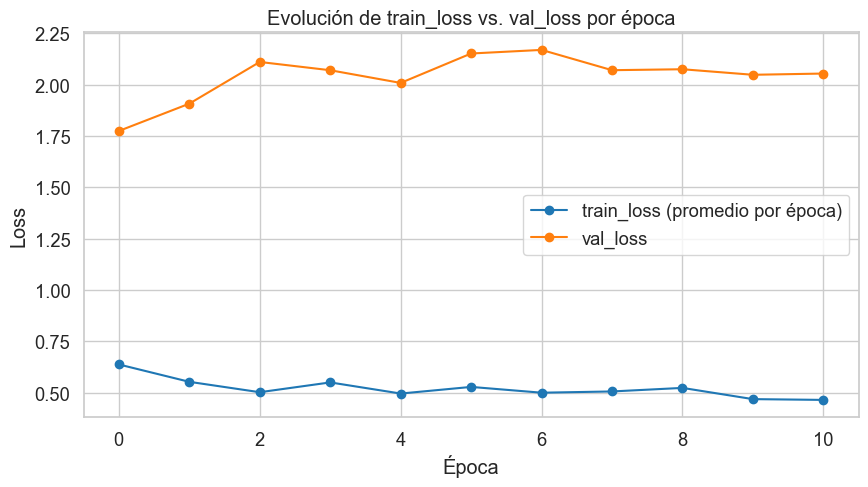

In [34]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

# Toma la versión más reciente de lightning_logs (la última corrida)
version_dirs = sorted(glob.glob("lightning_logs/version_*"), key=lambda p: int(p.split("_")[-1]))
ruta_metrics = f"{version_dirs[-1]}/metrics.csv"
print(f"Leyendo: {ruta_metrics}")

metrics = pd.read_csv(ruta_metrics)

# train_loss se loguea por STEP (varias filas por época) -> promedio por
# época para poder comparar contra val_loss (una fila por época, el resto NaN).
train_por_epoca = metrics.groupby("epoch")["train_loss"].mean()
val_por_epoca = metrics.groupby("epoch")["val_loss"].mean()

plt.figure(figsize=(10, 5))
plt.plot(train_por_epoca.index, train_por_epoca.values, marker="o", label="train_loss (promedio por época)")
plt.plot(val_por_epoca.index, val_por_epoca.values, marker="o", label="val_loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Evolución de train_loss vs. val_loss por época")
plt.legend()
plt.grid(True)
plt.show()

#### Definción de MAPE "robusto": ¿por qué MAPE da miles de millones de por ciento?

 El cálculo de MAPE con `evaluar_mape_r2` dio un número absurdo (miles de millones de %). Se investigó en dos pasos: 
* primero se revisó la distribución de `y_pred_reales`, resultando una distribución razonable, sin outliers extremos. 
* Segundo, se revisó `y_true_reales` cerca de cero (¿los "ceros" de meses de parada vuelven exactos después de des-normalizar?).

**Resultado del análisis**
*  los "ceros" (meses de parada, `prod_pet=0`) NO vuelven a dar exactamente `0.0` después de la ida y vuelta por `log1p`→z-score→`expm1`; quedan en el orden de `1e-9` por redondeo de `float32`. 
* El filtro original de `mean_absolute_percentage_error` (`y_true != 0`) no los excluye, y dividir por un número así de chico infla el promedio a valores sin sentido. 
* Esto motivó la definición `mape_robusto` que usa un piso mínimo (`|y_true| > 1 m³`)

In [35]:
print(pd.Series(resultado.y_pred_reales).describe())
print("\nTop 10 predicciones más altas:")
print(pd.Series(resultado.y_pred_reales).sort_values(ascending=False).head(10))

count    2460.000000
mean      224.299967
std       301.775624
min        -0.759019
25%        18.885382
50%       103.640409
75%       309.302146
max      2510.251097
dtype: float64

Top 10 predicciones más altas:
2403    2510.251097
2400    2357.397721
2408    2080.187971
1904    1898.221150
1899    1862.053894
2406    1808.751595
2402    1802.145038
2401    1723.443134
2410    1697.848042
2391    1681.768068
dtype: float64


In [36]:
print("y_true_reales — valores más cercanos a cero (en valor absoluto):")
print(pd.Series(resultado.y_true_reales).abs().sort_values().head(15))

y_true_reales — valores más cercanos a cero (en valor absoluto):
1901    4.186579e-09
1589    6.767722e-09
1588    6.767722e-09
318     7.081676e-09
316     7.081676e-09
315     7.081676e-09
314     7.081676e-09
317     7.081676e-09
320     7.081676e-09
319     7.081676e-09
313     7.081676e-09
323     7.081676e-09
312     7.081676e-09
321     7.081676e-09
322     7.081676e-09
dtype: float64


In [37]:
print(f"MAPE (robusto, umbral=1 m³): {resultado.mape_robusto:.2f}%")
print(f"Meses excluidos (|y_true| <= 1 m³): {resultado.meses_excluidos} de {resultado.n}")

MAPE (robusto, umbral=1 m³): 163.73%
Meses excluidos (|y_true| <= 1 m³): 469 de 2460


### 6.4 Visualización de predicciones

Se utilizan las utilidades de la Sección 5 sobre `val_seen` para ver ventanas concretas: una muestra aleatoria, y casos con/sin parada real en el horizonte.

Cada gráfico lo arma `graficar_pozos` (Sección 5), que llama a `plot_prediccion_individual` una vez por pozo. Muestra tres series: la historia usada como input (36 meses, azul), la producción real del horizonte a predecir (12 meses, negro) y la predicción del modelo (12 meses, rojo punteado).

Las franjas naranjas marcan los meses del horizonte donde el pozo tuvo una parada según el atributo `tipoestado_target` que se guarda en como "metadata". Ese atributo nunca es input del modelo: se guarda solo para diagnóstico posterior a la predicción

En la seccion 7.6 se realizará un análisis de las mejores y peores predicciones del modelo 

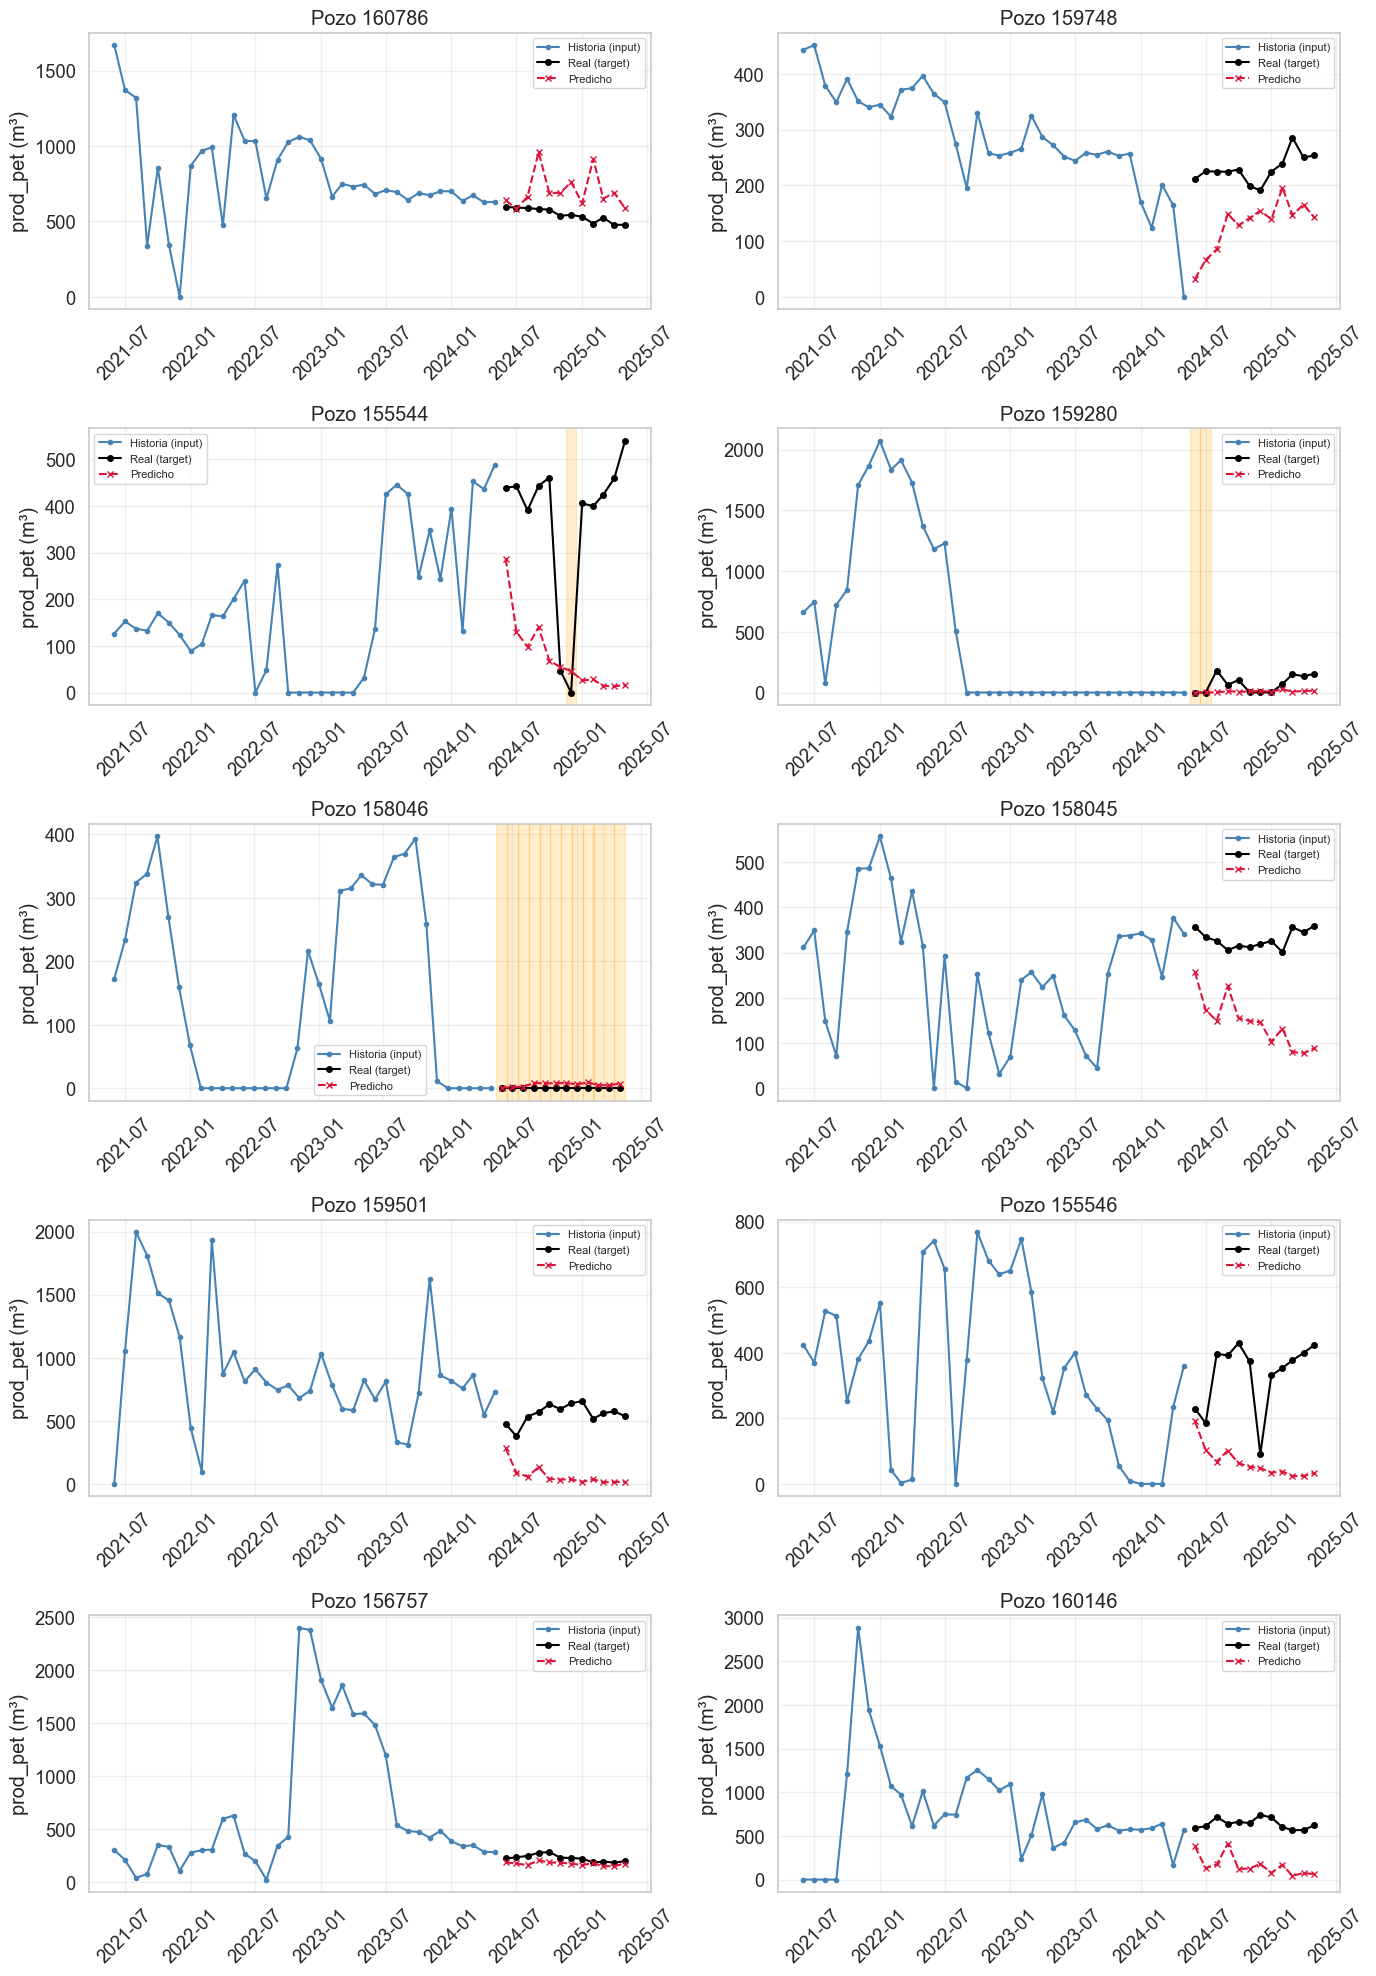

In [38]:
indices_random = seleccionar_ventanas_aleatorias(data_module.ds_val_seen, n=10)
graficar_pozos(model, data_module.ds_val_seen, indices_random, data_module.normalizacion)

Pozos CON al menos un mes de parada real en el horizonte -- son los casos donde el modelo no tiene forma de acertar (error irreducible por diseño).

Pozos con parada en el horizonte: 100 de 205


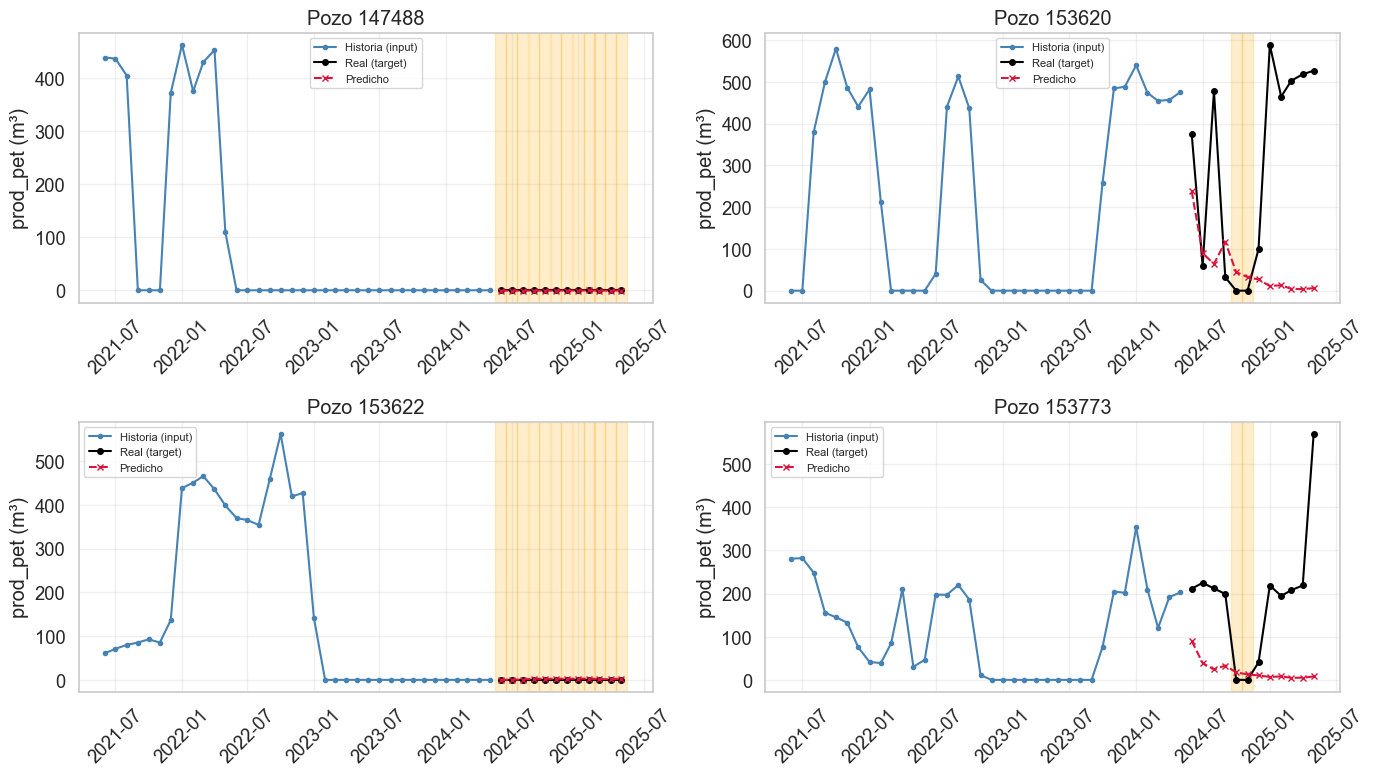

In [39]:
indices_con_parada = seleccionar_ventanas_con_parada(data_module.ds_val_seen, con_parada=True)
print(f"Pozos con parada en el horizonte: {len(indices_con_parada)} de {len(data_module.ds_val_seen)}")
graficar_pozos(model, data_module.ds_val_seen, indices_con_parada[:4], data_module.normalizacion)

## 7. Ejecución B — modelo minimizando paradas

Mismo modelo y mismo flujo que la Sección 6, entrenado sobre un subconjunto de pozos menos afectados por paradas administrativas/operativas, para dimensionar cuánto del error de la Ejecución A se podria explicar por esas paradas impredecibles

- **7.0 Análisis de umbral de parada**: evalúa distintas combinaciones de umbral de tasa (`paradas_por_anio`) y de racha máxima consecutiva (`racha_maxima_parada`), y cuántos pozos quedan disponibles en train/val/test bajo cada una. Elección final: `umbral=1` (a lo sumo 1 mes de parada por año en promedio) y `racha_maxima=2` (ningún bloque de más de 2 meses consecutivos de parada) 
- **7.1 Pipeline de datos**: filtra los pozos con ese criterio (`filtrar_pozos_por_parada`) y arma el `PozoDataModule` a partir del DataFrame ya filtrado 
- **7.2 Entrenamiento**: mismo modelo e hiperparámetros que la Sección 6.2, con checkpoints y logs en directorios separados (`checkpoints_b/`, `lightning_logs_b/`) para no pisar los resultados de la Ejecución A.
- **7.3 Resultados**: mismas métricas que 6.3 (MAPE "crudo" + `mape_robusto`).
- **7.5 Visualización**: mismas utilidades de la Sección 5, aplicadas sobre `val_seen` de la Ejecución B.

### 7.0 Análisis de umbral de parada

Para elegir qué tan restrictivo conviene ser al filtrar pozos "sin paradas", se considera que un mes está de parada si la producción real es casi nula, `prod_pet <= 1` m³ (`calcular_paradas_por_pozo` en `datasets.py`), sin considerar el estado declarado. Es más restrictivo porque también atrapa pozos "activos" administrativamente que producen casi nada.

Por pozo, sobre TODA su historia (sin restringir a train/val/test), se calcula la tasa `paradas_por_anio = meses_parada / (meses_totales/12)`, para poder comparar pozos con distinta cantidad de historia. La celda siguiente muestra cómo se distribuye esa tasa entre los pozos disponibles, antes de aplicar ningún umbral.

Pozos totales disponibles: 497
count    497.000000
mean       0.750028
std        0.910953
min        0.000000
25%        0.153846
50%        0.369231
75%        1.064516
max        5.040000
Name: paradas_por_anio, dtype: float64


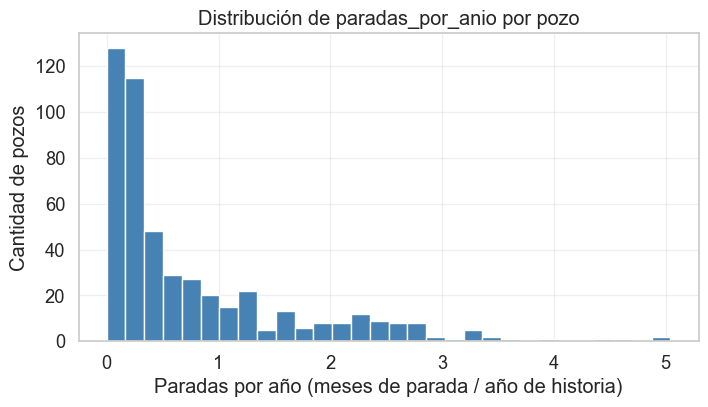

In [40]:
from datasets import (
    process_dataset,
    calcular_cortes_split,
    calcular_paradas_por_pozo,
    tabla_elegibilidad_por_umbral_parada,
    INPUT_LEN,
    TARGET_LEN,
    MIN_VENTANAS_TRAIN,
)

# df/cortes se recalculan acá de forma independiente (no se reusa
# data_module de la Sección 6.1) -- así la Sección 7 corre sola, sin
# depender de que se haya ejecutado el pipeline pesado de la Ejecución A.
# Con el mismo archivo y los mismos INPUT_LEN/TARGET_LEN/MIN_VENTANAS_TRAIN,
# el resultado es idéntico a data_module.cortes.
df = process_dataset("datos_modelo.csv")
cortes = calcular_cortes_split(df, input_len=INPUT_LEN, target_len=TARGET_LEN, min_ventanas_train=MIN_VENTANAS_TRAIN)

resumen_paradas = calcular_paradas_por_pozo(df, umbral_prod=1.0)
print(f"Pozos totales disponibles: {df['idpozo'].nunique()}")
print(resumen_paradas["paradas_por_anio"].describe())

plt.figure(figsize=(8, 4))
plt.hist(resumen_paradas["paradas_por_anio"], bins=30, color="steelblue", edgecolor="white")
plt.xlabel("Paradas por año (meses de parada / año de historia)")
plt.ylabel("Cantidad de pozos")
plt.title("Distribución de paradas_por_anio por pozo")
plt.grid(alpha=0.3)
plt.show()

Tabla cruzada: para los umbrales 0 (ninguna parada en toda la historia), 1 y 2 (a lo sumo 1/2 meses de parada por año en promedio), cuántos pozos filtrados quedan elegibles para train/val/test. `cortes` se calculó en la celda anterior de forma independiente de la Sección 6 -- con el mismo archivo y los mismos hiperparámetros (`INPUT_LEN`/`TARGET_LEN`/`MIN_VENTANAS_TRAIN` de `datasets.py`), da el mismo resultado que `data_module.cortes`, pero sin requerir que la Sección 6 se haya ejecutado antes.

In [41]:
tabla_umbrales = tabla_elegibilidad_por_umbral_parada(df, cortes, umbrales=[0, 1, 2])
tabla_umbrales

,pozos_totales,elegible_train,elegible_val,elegible_test
umbral,,,,
0,98,4,45,98
1,367,112,235,367
2,436,158,289,436


La tasa `paradas_por_anio` sola no alcanza: no distingue si esos meses de parada están repartidos a lo largo de la historia o concentrados en un único bloque largo (que igual puede arruinar una ventana de train/val/test). Se agrega `racha_maxima_parada` (meses consecutivos de parada más largos del pozo) y se re-corre la tabla para `umbral=1` combinando ambos criterios, con un tope de racha de 2 meses.

In [42]:
resumen_paradas = calcular_paradas_por_pozo(df, umbral_prod=1.0)
print("Distribución de racha_maxima_parada (meses consecutivos de parada, entre los pozos con umbral<=1):")
print(resumen_paradas.loc[resumen_paradas["paradas_por_anio"] <= 1, "racha_maxima_parada"].describe())

RACHA_MAXIMA = 2
tabla_umbrales_racha = tabla_elegibilidad_por_umbral_parada(df, cortes, umbrales=[0, 1, 2], racha_maxima=RACHA_MAXIMA)
tabla_umbrales_racha

Distribución de racha_maxima_parada (meses consecutivos de parada, entre los pozos con umbral<=1):
count    367.000000
mean       1.316076
std        1.268939
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        7.000000
Name: racha_maxima_parada, dtype: float64


,pozos_totales,elegible_train,elegible_val,elegible_test
umbral,,,,
0,98,4,45,98
1,314,80,195,314
2,316,80,197,316


### 7.1 Pipeline de datos

Se filtra a los pozos con `umbral=1` (a lo sumo 1 mes de parada por año en promedio) y `racha_maxima=2` (ningún bloque de más de 2 meses consecutivos de parada) -- la elección final de la Sección 7.1, priorizando limpieza de datos sobre tamaño de muestra.

Nota de diseño: de acá en adelante todas las variables de la Ejecución B llevan sufijo `_b` (`data_module_b`, `model_b`, `resultado_b`, ...), y los checkpoints/logs van a directorios separados (`checkpoints_b/`, `lightning_logs_b/`) -- así no se pisan los resultados de la Ejecución A (Sección 6), necesarios para la comparación final de la Sección 8.

In [43]:
from datasets import filtrar_pozos_por_parada, PozoDataModule

UMBRAL_PARADA = 1
RACHA_MAXIMA_PARADA = 2

df_filtrado = filtrar_pozos_por_parada(df, umbral=UMBRAL_PARADA, racha_maxima=RACHA_MAXIMA_PARADA)
print(f"Pozos tras filtrar (umbral={UMBRAL_PARADA}, racha_maxima={RACHA_MAXIMA_PARADA}): {df_filtrado['idpozo'].nunique()} de {df['idpozo'].nunique()}")

data_module_b = PozoDataModule.from_dataframe(
    df_filtrado,
    batch_size=32,
    input_len=INPUT_LEN,
    target_len=TARGET_LEN,
    min_ventanas_train=MIN_VENTANAS_TRAIN,
)
data_module_b.setup()

Pozos tras filtrar (umbral=1, racha_maxima=2): 314 de 497


### 7.2 Entrenamiento

In [44]:
ENTRENAR_B = True  # poner en False para saltear el entrenamiento y reusar el checkpoint ya guardado en checkpoints_b/ -- más práctico para iterar sobre el resto de la notebook.

model_b, resultado_b = entrenar_y_evaluar_config(
    data_module_b,
    nombre_config="Ejecución B",
    dirpath_checkpoints="./checkpoints_b/",
    nombre_logs="lightning_logs_b",
    entrenar=ENTRENAR_B,
    hidden_dim=64,
    num_layers=2,
    nhead=4,
    dropout=0.1,
    learning_rate=1e-3,
)
print(resultado_b)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== Ejecución B: entrenando ===


c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\ignsagul\OneDrive - Publicis Groupe\MMA\14_Deep Learning\tp-final\checkpoints_b exists and is not empty.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ input_projection         │ Linear             │    832 │ train │     0 │
│ 1 │ decoder_input_projection │ Linear             │    832 │ train │     0 │
│ 2 │ encoder                  │ TransformerEncoder │  562 K │ train │     0 │
│ 3 │ decoder                  │ TransformerDecoder │  595 K │ train │     0 │
│ 4 │ pos_encoder              │ PositionalEncoding │      0 │ train │     0 │
│ 5 │ decoder_pos_embedding    │ Embedding          │    768 │ train │     0 │
│ 6 │ output_projection        │ Linear             │     65 │ train │     0 │
└───┴──────────────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 1.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.2 M                                                                                                
Total estimated model params size (MB): 4.643                                                                      
Modules in train mode: 58                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │     1.248273253440857     │
│         test_mae          │    0.7363511919975281     │
└───────────────────────────┴───────────────────────────┘

Test results: [{'test_loss': 1.248273253440857, 'test_mae': 0.7363511919975281}]
Cargando checkpoint: C:\Users\ignsagul\OneDrive - Publicis Groupe\MMA\14_Deep Learning\tp-final\checkpoints_b\lstm-epoch=08-val_loss=1.12-v1.ckpt

=== Ejecución B: evaluación (val_seen) ===


c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


n = 960 valores (pozo-mes)
MAPE: 48137829008.50%
R²  : 0.0611
MAPE robusto (umbral=1 m³): 145.52%  (excluye 29 de 960 meses casi-nulos)
[Ejecución B]
  n               = 960
  MAPE            = 48137829008.50%
  R²              = 0.0611
  MAPE robusto    = 145.52%
  Meses excluidos = 29 de 960


### 7.3 Resultados

Leyendo: lightning_logs_b\version_1/metrics.csv


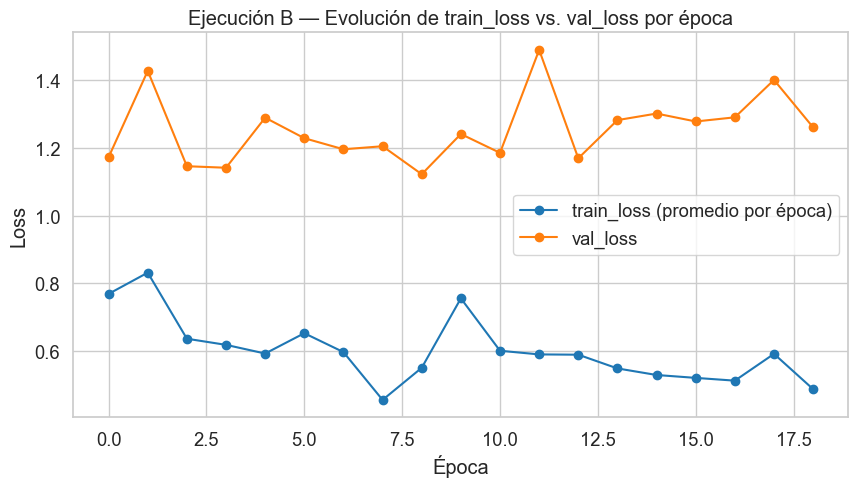

In [45]:
version_dirs_b = sorted(glob.glob("lightning_logs_b/version_*"), key=lambda p: int(p.split("_")[-1]))
ruta_metrics_b = f"{version_dirs_b[-1]}/metrics.csv"
print(f"Leyendo: {ruta_metrics_b}")

metrics_b = pd.read_csv(ruta_metrics_b)
train_por_epoca_b = metrics_b.groupby("epoch")["train_loss"].mean()
val_por_epoca_b = metrics_b.groupby("epoch")["val_loss"].mean()

plt.figure(figsize=(10, 5))
plt.plot(train_por_epoca_b.index, train_por_epoca_b.values, marker="o", label="train_loss (promedio por época)")
plt.plot(val_por_epoca_b.index, val_por_epoca_b.values, marker="o", label="val_loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Ejecución B — Evolución de train_loss vs. val_loss por época")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
print(f"MAPE (robusto, umbral=1 m³): {resultado_b.mape_robusto:.2f}%")
print(f"Meses excluidos (|y_true| <= 1 m³): {resultado_b.meses_excluidos} de {resultado_b.n}")

MAPE (robusto, umbral=1 m³): 145.52%
Meses excluidos (|y_true| <= 1 m³): 29 de 960


### 7.4 Visualización de predicciones

Mismas utilidades de la Sección 5, ahora sobre `val_seen` de la Ejecución B. Algunas observaciones:

- **Reactivación tras una caída**: pozo 160575 -- la producción cae a casi cero y luego se recupera a niveles similares o mayores a los previos; la predicción se queda plana/declinando, sin capturar la recuperación.
- **Incremento súbito de varias veces la producción previa**: pozos 160694 y 156757 -- saltos de magnitud consistentes con una re-fractura o *workover*, no con una fluctuación normal de declive.

Esta evidencia se retoma en las Conclusiones


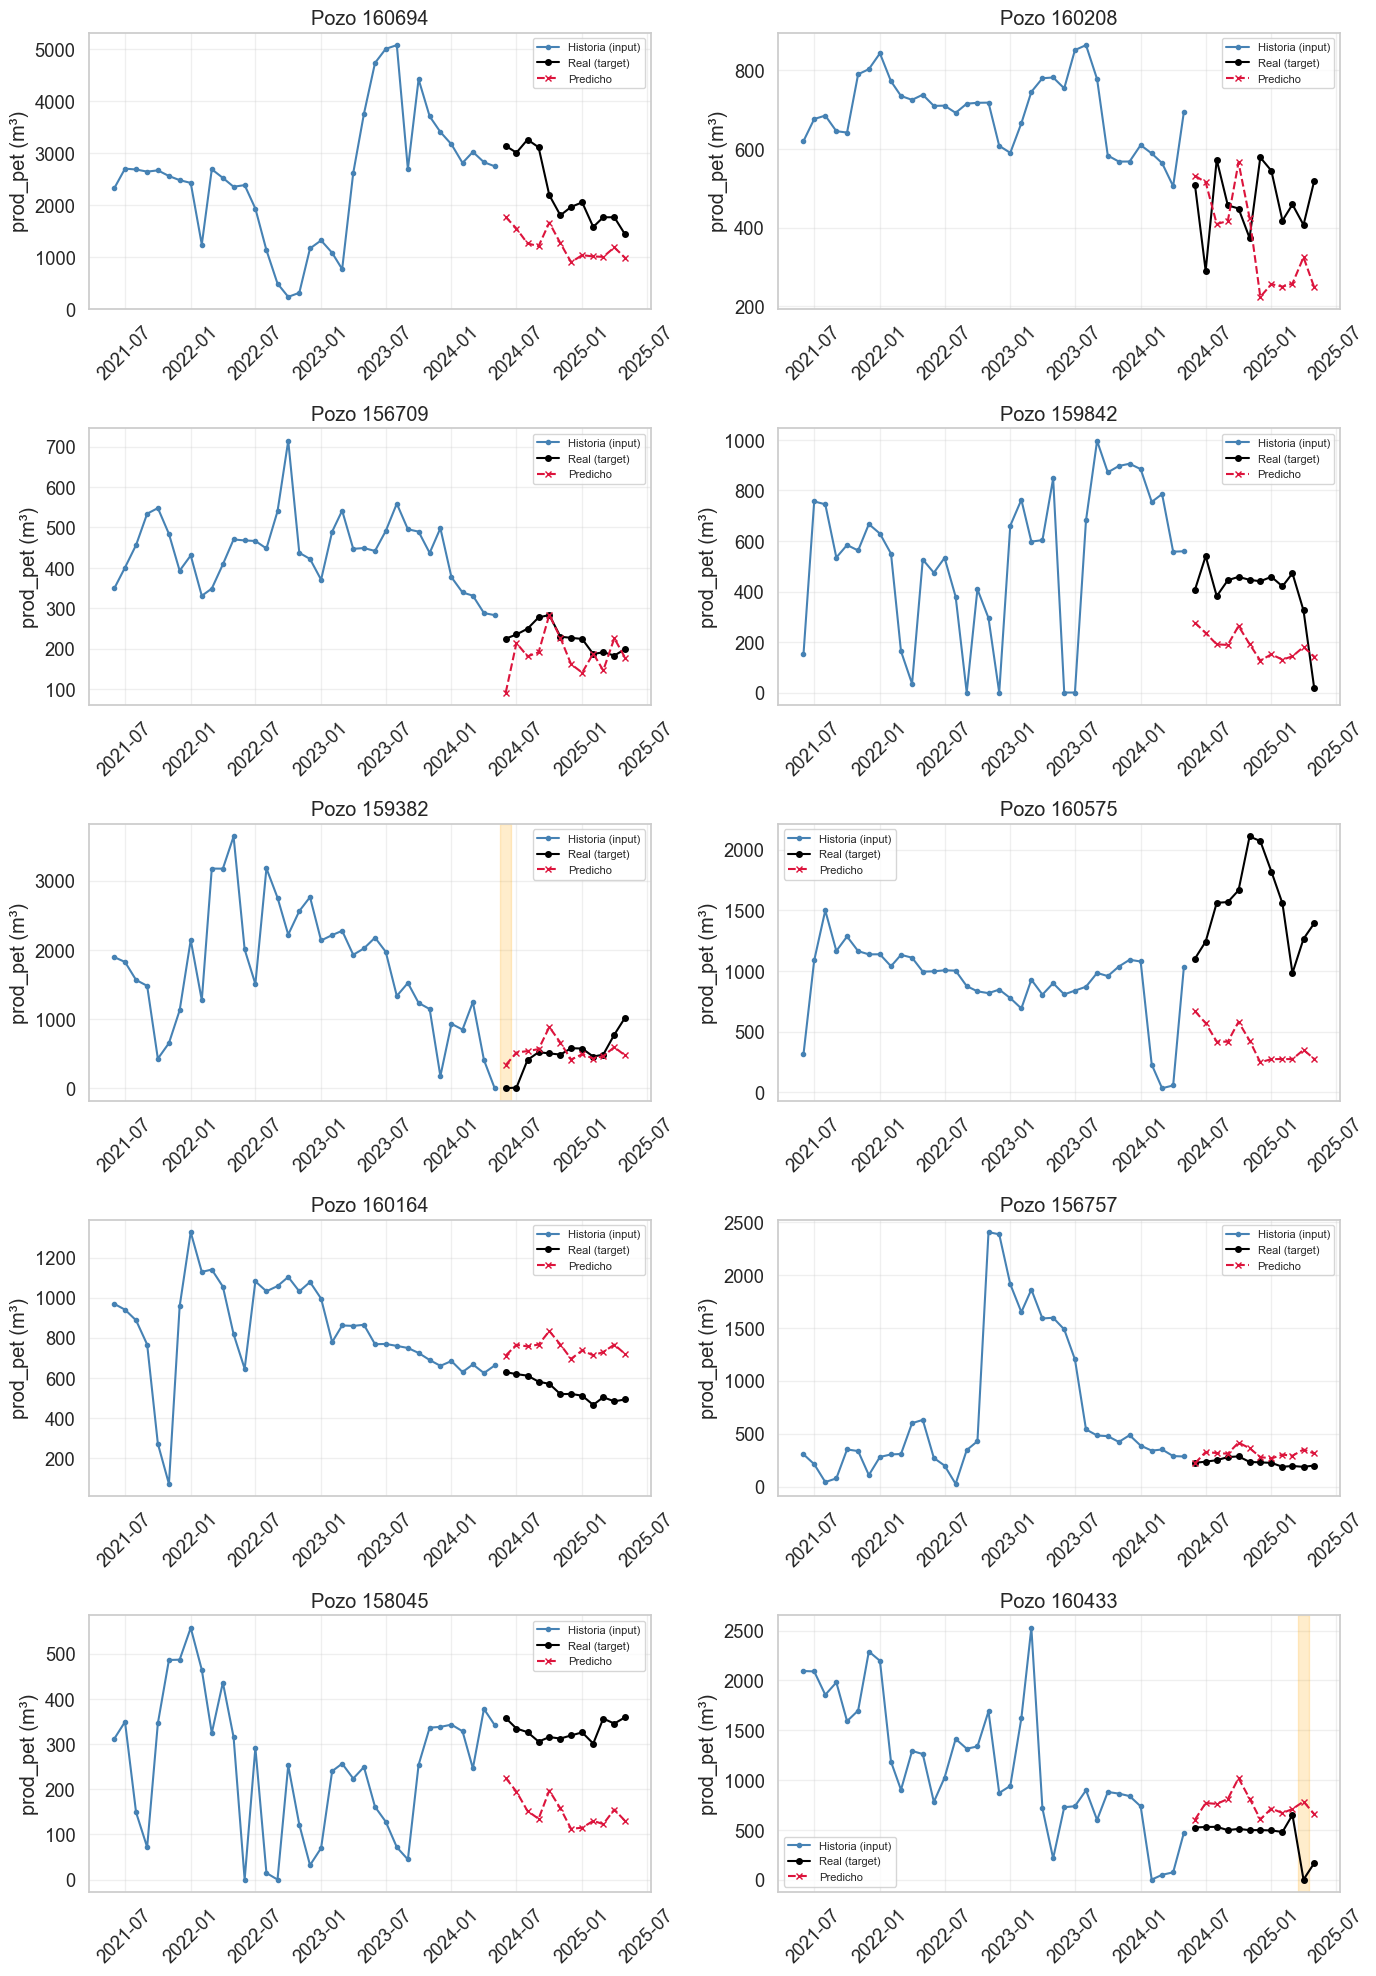

In [47]:
indices_random_b = seleccionar_ventanas_aleatorias(data_module_b.ds_val_seen, n=10)
graficar_pozos(model_b, data_module_b.ds_val_seen, indices_random_b, data_module_b.normalizacion)

Pozos con parada en el horizonte: 22 de 80


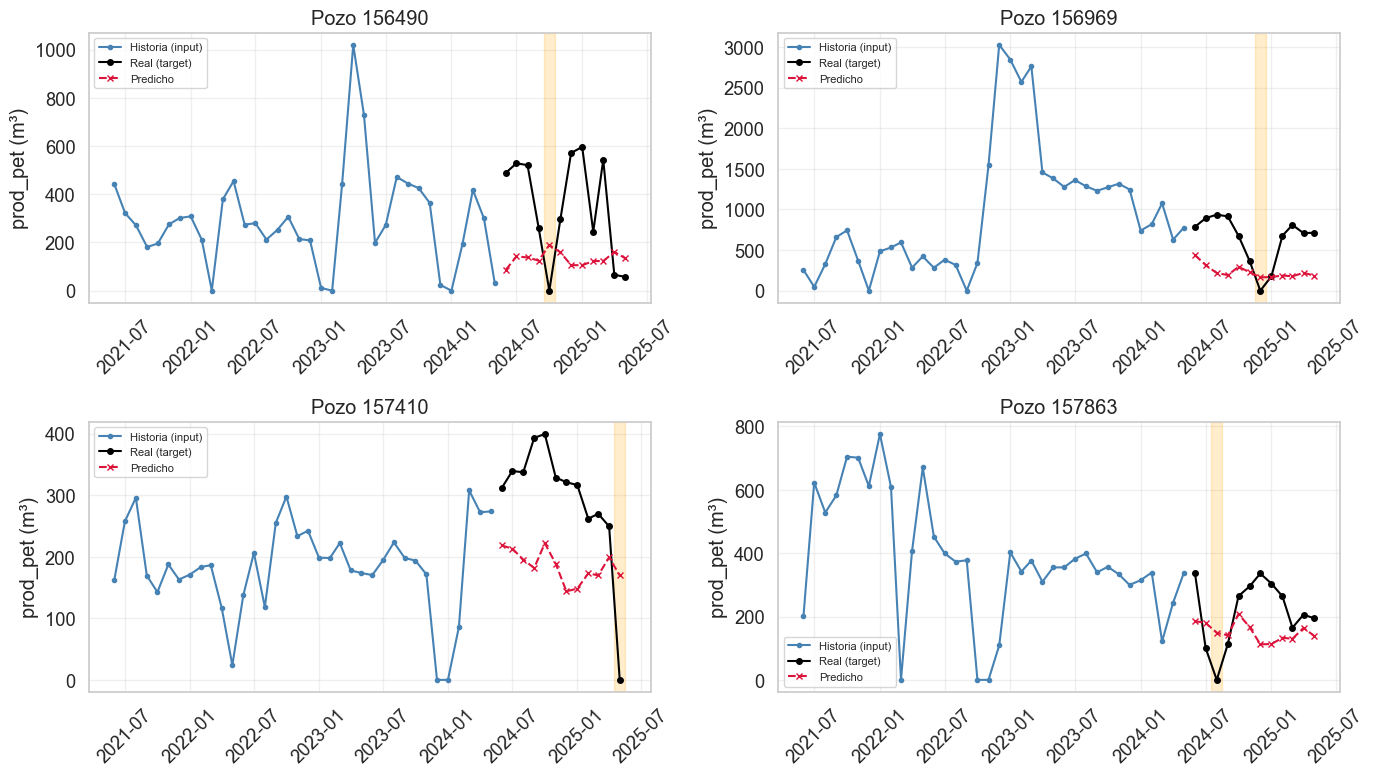

In [48]:
indices_con_parada_b = seleccionar_ventanas_con_parada(data_module_b.ds_val_seen, con_parada=True)
print(f"Pozos con parada en el horizonte: {len(indices_con_parada_b)} de {len(data_module_b.ds_val_seen)}")
graficar_pozos(model_b, data_module_b.ds_val_seen, indices_con_parada_b[:4], data_module_b.normalizacion)

### 7.5 Ajuste de hiperparámetros

Se prueban 4 variaciones sobre la configuración de la Ejecución B (Sección 7.3), reusando el mismo `data_module_b`:

| Config | `learning_rate` | `hidden_dim` | `patience` | `max_epochs` |
|---|---|---|---|---|
| Baseline B | 1e-3 | 64 | 10 | 20 |
| HP1 | 3e-4 | 64 | 15 | 30 |
| HP2 | 1e-3 | 128 | 15 | 30 |
| HP1 extendido | 3e-4 | 64 | 30 | 100 |
| HP3 | 3e-4 | 128 | 15 | 30 |

El resto de los hiperparámetros (`num_layers=2`, `nhead=4`, `dropout=0.1`) se mantiene igual en todas.

**Nota sobre consulta previa por mail**: antes de esta sección se fijó una semilla aleatoria (`SEED=42`, Sección 2), que no estaba fija cuando se envió la notebook con la consulta a Paolo. Los números de ese mail (R²≈-0,07 en A, ≈0,19 en B) corresponden a corridas sin esa semilla. No son directamente comparables con los resultados de esta notebook.

#### Lógica de las configuraciones probadas

**HP1 (`learning_rate=3e-4`)**: en el baseline B, val_loss mejora hasta la época 8 y después queda en una meseta ruidosa (1,12–1,49) sin tendencia. Este patrón puede presentarse por learning rate alto (el modelo "rebota" en vez de asentarse). Entonces en esta configuración, se prueba reduciéndolo a un tercio.

**HP2 (`hidden_dim=128`)**: prueba si el modelo mejora su desempeño al incrementar la dimensión oculta.

**HP1 extendido (`patience=30`, `max_epochs=100`, mismo LR y `hidden_dim` que HP1)**: HP1 mejoró una sola vez (en la época 0) y después no se movió en 15 épocas. No queda claro por qué. Puede ser que ya encontró un buen punto y no hace falta más. O puede ser que con ese LR más chico necesite más épocas para seguir mejorando. Se aumentó la cantidad de épocas, sin cambiar nada más, para ver el resultado.

**HP3 (`learning_rate=3e-4` + `hidden_dim=128` combinados)**: explora si combinar los cambios de HP1 y HP2 mejora el resultado.


In [49]:
ENTRENAR_HP1 = True  # poner en False para saltear el entrenamiento y reusar el checkpoint ya guardado en checkpoints_b_hp1/ -- más práctico para iterar sobre el resto de la notebook.

model_hp1, resultado_hp1 = entrenar_y_evaluar_config(
    data_module_b,
    nombre_config="Ejecución B - HP1 (lr=3e-4)",
    dirpath_checkpoints="./checkpoints_b_hp1/",
    nombre_logs="lightning_logs_b_hp1",
    entrenar=ENTRENAR_HP1,
    max_epochs=30,
    patience=15,
    hidden_dim=64,
    num_layers=2,
    nhead=4,
    dropout=0.1,
    learning_rate=3e-4,
)
print(resultado_hp1)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== Ejecución B - HP1 (lr=3e-4): entrenando ===


c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\ignsagul\OneDrive - Publicis Groupe\MMA\14_Deep Learning\tp-final\checkpoints_b_hp1 exists and is not empty.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ input_projection         │ Linear             │    832 │ train │     0 │
│ 1 │ decoder_input_projection │ Linear             │    832 │ train │     0 │
│ 2 │ encoder                  │ TransformerEncoder │  562 K │ train │     0 │
│ 3 │ decoder                  │ TransformerDecoder │  595 K │ train │     0 │
│ 4 │ pos_encoder              │ PositionalEncoding │      0 │ train │     0 │
│ 5 │ decoder_pos_embedding    │ Embedding          │    768 │ train │     0 │
│ 6 │ output_projection        │ Linear             │     65 │ train │     0 │
└───┴──────────────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 1.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.2 M                                                                                                
Total estimated model params size (MB): 4.643                                                                      
Modules in train mode: 58                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │     1.259089708328247     │
│         test_mae          │    0.7045280933380127     │
└───────────────────────────┴───────────────────────────┘

Test results: [{'test_loss': 1.259089708328247, 'test_mae': 0.7045280933380127}]
Cargando checkpoint: C:\Users\ignsagul\OneDrive - Publicis Groupe\MMA\14_Deep Learning\tp-final\checkpoints_b_hp1\lstm-epoch=00-val_loss=1.10-v1.ckpt

=== Ejecución B - HP1 (lr=3e-4): evaluación (val_seen) ===


c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


n = 960 valores (pozo-mes)
MAPE: 43452033254.45%
R²  : 0.1062
MAPE robusto (umbral=1 m³): 144.93%  (excluye 29 de 960 meses casi-nulos)
[Ejecución B - HP1 (lr=3e-4)]
  n               = 960
  MAPE            = 43452033254.45%
  R²              = 0.1062
  MAPE robusto    = 144.93%
  Meses excluidos = 29 de 960


In [50]:
ENTRENAR_HP2 = True  # poner en False para saltear el entrenamiento y reusar el checkpoint ya guardado en checkpoints_b_hp2/ -- más práctico para iterar sobre el resto de la notebook.

model_hp2, resultado_hp2 = entrenar_y_evaluar_config(
    data_module_b,
    nombre_config="Ejecución B - HP2 (hidden_dim=128)",
    dirpath_checkpoints="./checkpoints_b_hp2/",
    nombre_logs="lightning_logs_b_hp2",
    entrenar=ENTRENAR_HP2,
    max_epochs=30,
    patience=15,
    hidden_dim=128,
    num_layers=2,
    nhead=4,
    dropout=0.1,
    learning_rate=1e-3,
)
print(resultado_hp2)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== Ejecución B - HP2 (hidden_dim=128): entrenando ===


c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\ignsagul\OneDrive - Publicis Groupe\MMA\14_Deep Learning\tp-final\checkpoints_b_hp2 exists and is not empty.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ input_projection         │ Linear             │  1.7 K │ train │     0 │
│ 1 │ decoder_input_projection │ Linear             │  1.7 K │ train │     0 │
│ 2 │ encoder                  │ TransformerEncoder │  1.2 M │ train │     0 │
│ 3 │ decoder                  │ TransformerDecoder │  1.3 M │ train │     0 │
│ 4 │ pos_encoder              │ PositionalEncoding │      0 │ train │     0 │
│ 5 │ decoder_pos_embedding    │ Embedding          │  1.5 K │ train │     0 │
│ 6 │ output_projection        │ Linear             │    129 │ train │     0 │
└───┴──────────────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 2.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.5 M                                                                                                
Total estimated model params size (MB): 10.039                                                                     
Modules in train mode: 58                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    2.2146716117858887     │
│         test_mae          │    1.0182530879974365     │
└───────────────────────────┴───────────────────────────┘

Test results: [{'test_loss': 2.2146716117858887, 'test_mae': 1.0182530879974365}]
Cargando checkpoint: C:\Users\ignsagul\OneDrive - Publicis Groupe\MMA\14_Deep Learning\tp-final\checkpoints_b_hp2\lstm-epoch=03-val_loss=1.07-v1.ckpt

=== Ejecución B - HP2 (hidden_dim=128): evaluación (val_seen) ===


c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


n = 960 valores (pozo-mes)
MAPE: 44823489515.27%
R²  : 0.0364
MAPE robusto (umbral=1 m³): 139.56%  (excluye 29 de 960 meses casi-nulos)
[Ejecución B - HP2 (hidden_dim=128)]
  n               = 960
  MAPE            = 44823489515.27%
  R²              = 0.0364
  MAPE robusto    = 139.56%
  Meses excluidos = 29 de 960


In [51]:
ENTRENAR_HP1_EXT = True

model_hp1_ext, resultado_hp1_ext = entrenar_y_evaluar_config(
    data_module_b,
    nombre_config="Ejecución B - HP1 extendido (lr=3e-4, más épocas)",
    dirpath_checkpoints="./checkpoints_b_hp1_ext/",
    nombre_logs="lightning_logs_b_hp1_ext",
    entrenar=ENTRENAR_HP1_EXT,
    max_epochs=100,
    patience=30,
    hidden_dim=64,
    num_layers=2,
    nhead=4,
    dropout=0.1,
    learning_rate=3e-4,
)
print(resultado_hp1_ext)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== Ejecución B - HP1 extendido (lr=3e-4, más épocas): entrenando ===


c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\ignsagul\OneDrive - Publicis Groupe\MMA\14_Deep Learning\tp-final\checkpoints_b_hp1_ext exists and is not empty.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ input_projection         │ Linear             │    832 │ train │     0 │
│ 1 │ decoder_input_projection │ Linear             │    832 │ train │     0 │
│ 2 │ encoder                  │ TransformerEncoder │  562 K │ train │     0 │
│ 3 │ decoder                  │ TransformerDecoder │  595 K │ train │     0 │
│ 4 │ pos_encoder              │ PositionalEncoding │      0 │ train │     0 │
│ 5 │ decoder_pos_embedding    │ Embedding          │    768 │ train │     0 │
│ 6 │ output_projection        │ Linear             │     65 │ train │     0 │
└───┴──────────────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 1.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.2 M                                                                                                
Total estimated model params size (MB): 4.643                                                                      
Modules in train mode: 58                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │     1.809072494506836     │
│         test_mae          │    0.9252913594245911     │
└───────────────────────────┴───────────────────────────┘

Test results: [{'test_loss': 1.809072494506836, 'test_mae': 0.9252913594245911}]
Cargando checkpoint: C:\Users\ignsagul\OneDrive - Publicis Groupe\MMA\14_Deep Learning\tp-final\checkpoints_b_hp1_ext\lstm-epoch=01-val_loss=1.08-v1.ckpt

=== Ejecución B - HP1 extendido (lr=3e-4, más épocas): evaluación (val_seen) ===


c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


n = 960 valores (pozo-mes)
MAPE: 47367455812.60%
R²  : 0.1718
MAPE robusto (umbral=1 m³): 139.44%  (excluye 29 de 960 meses casi-nulos)
[Ejecución B - HP1 extendido (lr=3e-4, más épocas)]
  n               = 960
  MAPE            = 47367455812.60%
  R²              = 0.1718
  MAPE robusto    = 139.44%
  Meses excluidos = 29 de 960


In [52]:
ENTRENAR_HP3 = True

model_hp3, resultado_hp3 = entrenar_y_evaluar_config(
    data_module_b,
    nombre_config="Ejecución B - HP3 (lr=3e-4, hidden_dim=128)",
    dirpath_checkpoints="./checkpoints_b_hp3/",
    nombre_logs="lightning_logs_b_hp3",
    entrenar=ENTRENAR_HP3,
    max_epochs=30,
    patience=15,
    hidden_dim=128,
    num_layers=2,
    nhead=4,
    dropout=0.1,
    learning_rate=3e-4,
)
print(resultado_hp3)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== Ejecución B - HP3 (lr=3e-4, hidden_dim=128): entrenando ===


c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\ignsagul\OneDrive - Publicis Groupe\MMA\14_Deep Learning\tp-final\checkpoints_b_hp3 exists and is not empty.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ input_projection         │ Linear             │  1.7 K │ train │     0 │
│ 1 │ decoder_input_projection │ Linear             │  1.7 K │ train │     0 │
│ 2 │ encoder                  │ TransformerEncoder │  1.2 M │ train │     0 │
│ 3 │ decoder                  │ TransformerDecoder │  1.3 M │ train │     0 │
│ 4 │ pos_encoder              │ PositionalEncoding │      0 │ train │     0 │
│ 5 │ decoder_pos_embedding    │ Embedding          │  1.5 K │ train │     0 │
│ 6 │ output_projection        │ Linear             │    129 │ train │     0 │
└───┴──────────────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 2.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.5 M                                                                                                
Total estimated model params size (MB): 10.039                                                                     
Modules in train mode: 58                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    1.4841805696487427     │
│         test_mae          │    0.8407210111618042     │
└───────────────────────────┴───────────────────────────┘

Test results: [{'test_loss': 1.4841805696487427, 'test_mae': 0.8407210111618042}]
Cargando checkpoint: C:\Users\ignsagul\OneDrive - Publicis Groupe\MMA\14_Deep Learning\tp-final\checkpoints_b_hp3\lstm-epoch=01-val_loss=1.09-v1.ckpt

=== Ejecución B - HP3 (lr=3e-4, hidden_dim=128): evaluación (val_seen) ===


c:\Users\ignsagul\AppData\Local\anaconda3\envs\pytorch\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


n = 960 valores (pozo-mes)
MAPE: 35704573864.34%
R²  : 0.0629
MAPE robusto (umbral=1 m³): 133.92%  (excluye 29 de 960 meses casi-nulos)
[Ejecución B - HP3 (lr=3e-4, hidden_dim=128)]
  n               = 960
  MAPE            = 35704573864.34%
  R²              = 0.0629
  MAPE robusto    = 133.92%
  Meses excluidos = 29 de 960


### 7.6 Análisis visual: mejores y peores predicciones (HP1 extendido)

Se grafican a continuación las 6 mejores y las 6 peores predicciones según MAPE robusto, sobre `val_seen`, para la mejor configuración (HP1 extendido).

* **Mejores 6** (MAPE 8,5% a 23,9%): ninguna tiene un cambio de régimen nuevo *dentro* de la ventana de predicción. La mayoría son trayectorias estables o en declive suave. El pozo 160694 tuvo un salto en su producción, pero ya había ocurrido *antes* del horizonte a predecir, el modelo solo tuvo que continuar la tendencia post-salto, no anticiparlo.
* **Peores 6** (MAPE 419% a 2013%): en 5 casos, la producción real cae a niveles casi nulos *dentro* de la ventana de predicción, varios marcados como parada real según `tipoestado`. El pozo 159005 es distinto: la producción real es mayormente muy baja (9-21 m³) con dos picos aislados, mientras el modelo predice un nivel más alto y sostenido (~90-140 m³) todo el horizonte. Los últimos meses de historia muestran que el pozo ya había caído a un nivel bajo, pero la mayor parte de los 36 meses de entrada tuvo niveles mucho más altos. El error podría deberse a que el modelo se ancla al nivel promedio histórico del pozo

**Conclusión**: en la mayoría de los peores casos, la dificultad depende de si el cambio de régimen (una parada) cae dentro de los 12 meses que se están prediciendo.  Las mejores predicciones ocurren cuando las ventanas de prediccion tienen trayectorias estables o en declive suave



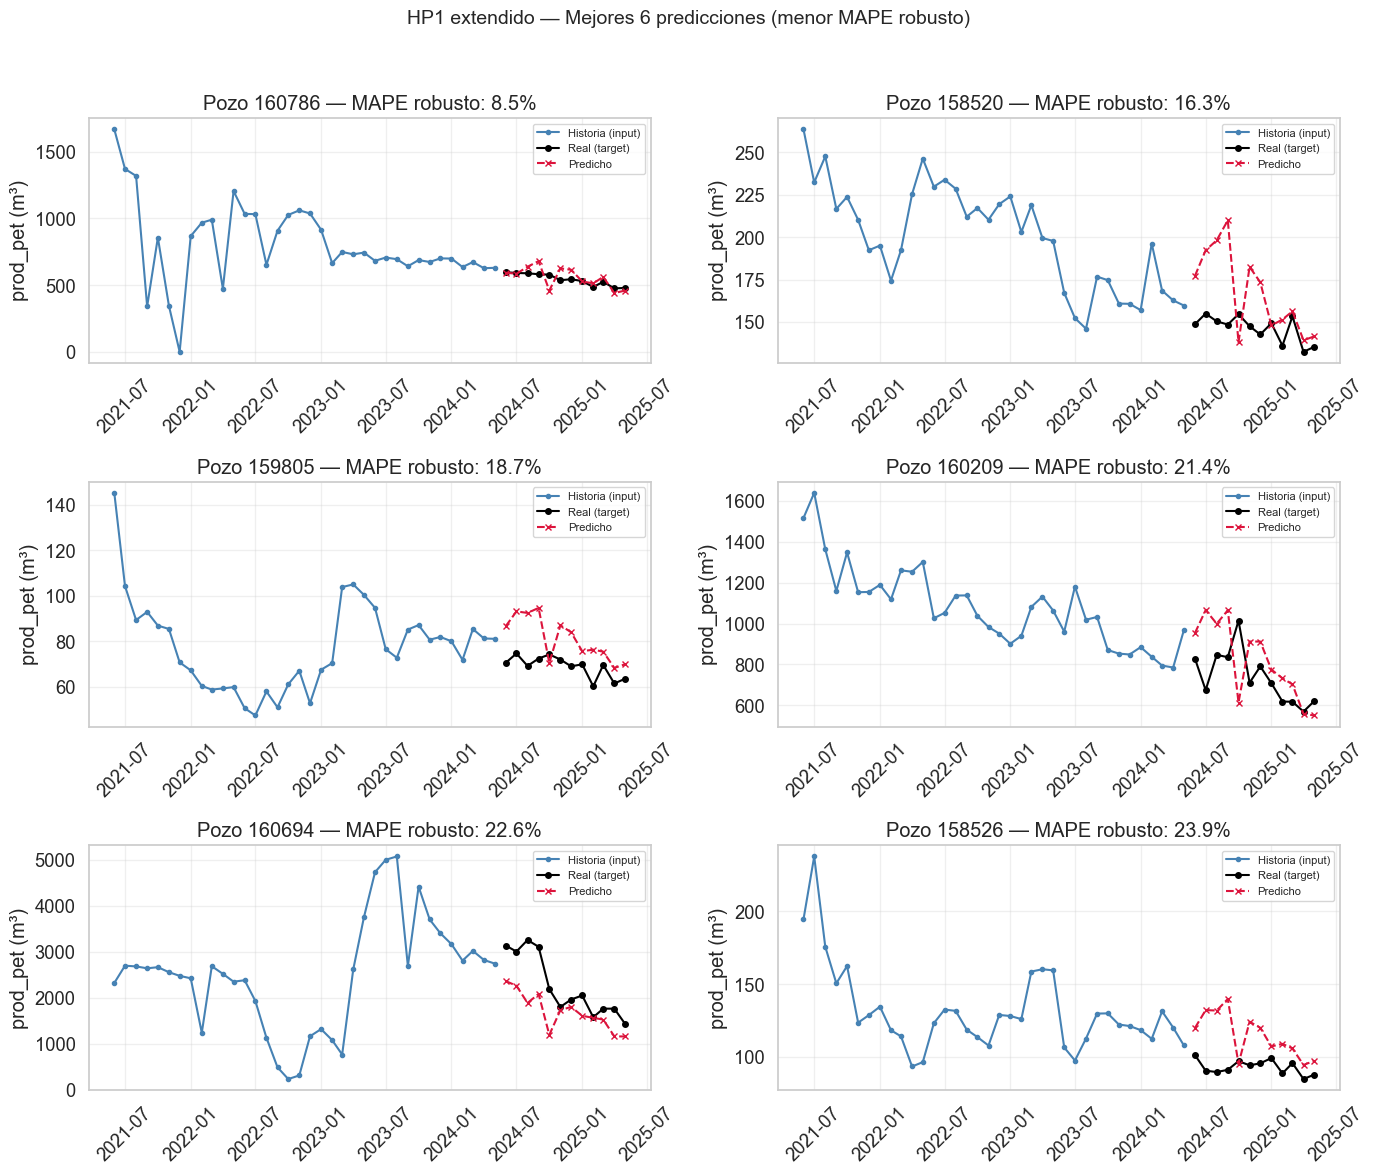

In [53]:
indices_mejores = seleccionar_ventanas_por_error(model_hp1_ext, data_module_b.ds_val_seen, data_module_b.normalizacion, top_n=6, peor=False)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, idx in zip(axes.flat, indices_mejores):
    prediccion = obtener_prediccion_ventana(model_hp1_ext, data_module_b.ds_val_seen, idx, data_module_b.normalizacion)
    mape_ventana = mape_robusto(prediccion["y_true_real"], prediccion["y_pred_real"])
    graficar_prediccion_pozo(prediccion, ax=ax)
    ax.set_title(f"Pozo {prediccion['idpozo']} — MAPE robusto: {mape_ventana:.1f}%")

fig.suptitle("HP1 extendido — Mejores 6 predicciones (menor MAPE robusto)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


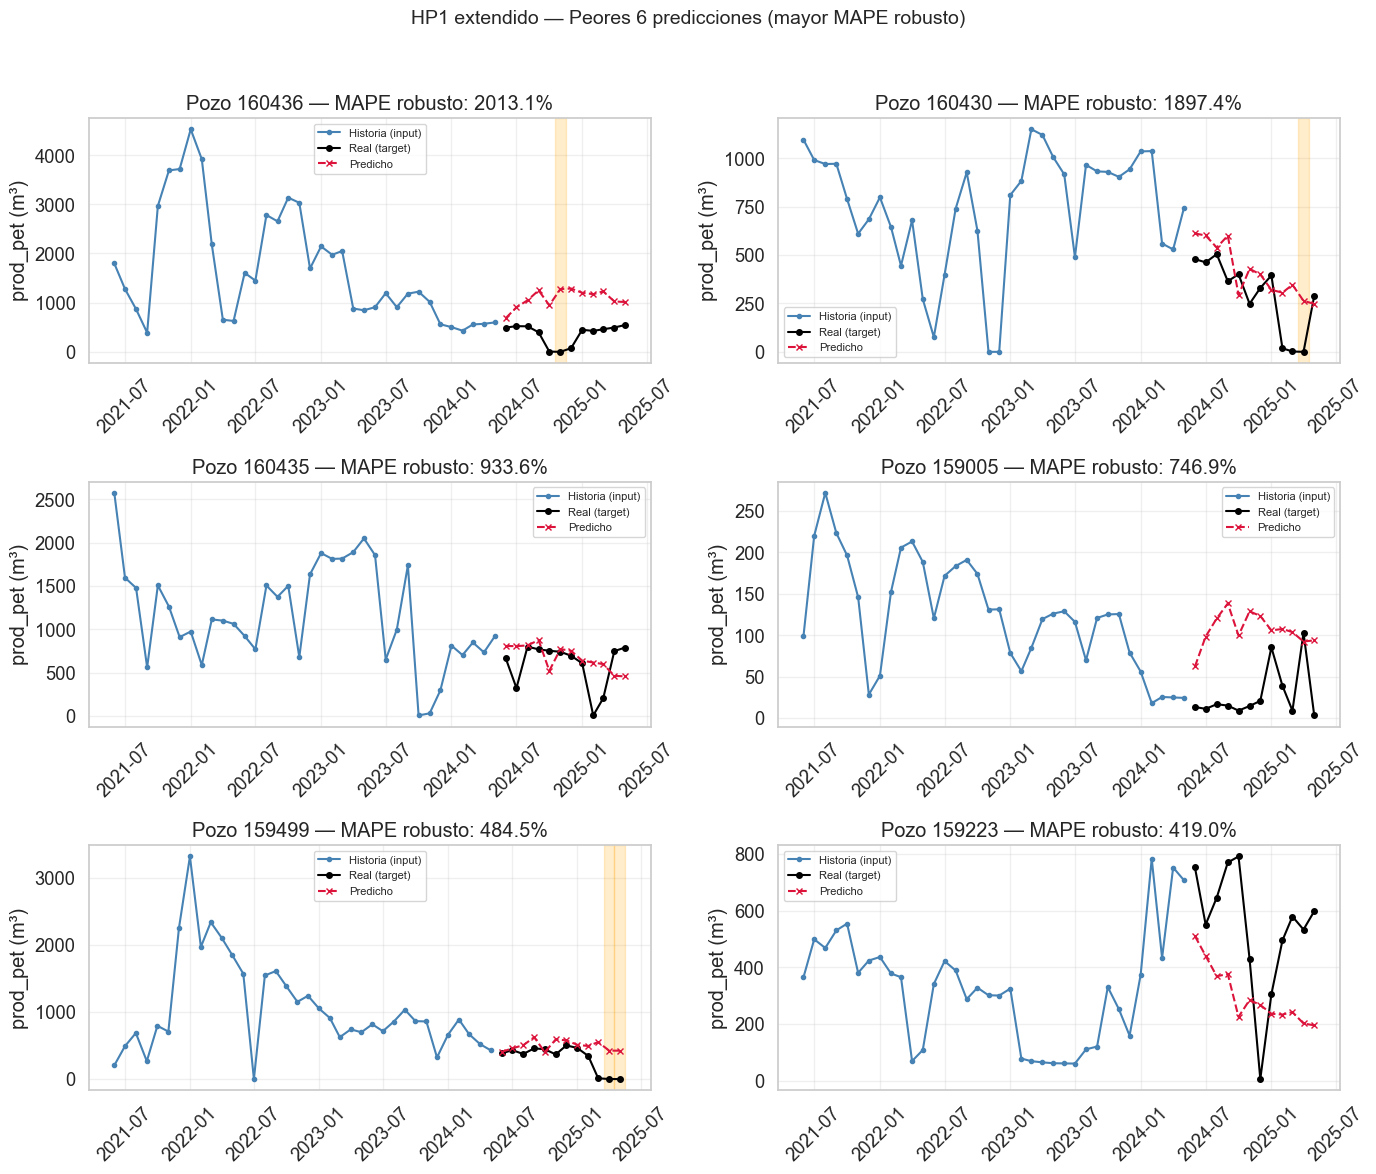

In [54]:
indices_peores = seleccionar_ventanas_por_error(model_hp1_ext, data_module_b.ds_val_seen, data_module_b.normalizacion, top_n=6, peor=True)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, idx in zip(axes.flat, indices_peores):
    prediccion = obtener_prediccion_ventana(model_hp1_ext, data_module_b.ds_val_seen, idx, data_module_b.normalizacion)
    mape_ventana = mape_robusto(prediccion["y_true_real"], prediccion["y_pred_real"])
    graficar_prediccion_pozo(prediccion, ax=ax)
    ax.set_title(f"Pozo {prediccion['idpozo']} — MAPE robusto: {mape_ventana:.1f}%")

fig.suptitle("HP1 extendido — Peores 6 predicciones (mayor MAPE robusto)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


###  7.7 Ejecución en test

In [55]:
resultado_hp1_ext_test = evaluar_mape_r2(model_hp1_ext, data_module_b.test_dataloader(), data_module_b.normalizacion)
resultado_hp1_ext_test.nombre_config = "Ejecución B - HP1 extendido (test)"
print(resultado_hp1_ext_test)


n = 960 valores (pozo-mes)
MAPE: 132284715782.90%
R²  : 0.2555
MAPE robusto (umbral=1 m³): 113.51%  (excluye 17 de 960 meses casi-nulos)
[Ejecución B - HP1 extendido (test)]
  n               = 960
  MAPE            = 132284715782.90%
  R²              = 0.2555
  MAPE robusto    = 113.51%
  Meses excluidos = 17 de 960


## 8. Comparación y conclusiones



### 8.1  Comparacion entre modelos 

Métricas y análisis de resultados de las Ejecuciones A y B , sobre validacion en ambos casos. El mejor modelo "HP1 extendido" se evalua además en test.

In [59]:
corridas = [
    (resultado, data_module),
    (resultado_b, data_module_b),
    (resultado_hp1, data_module_b),
    (resultado_hp2, data_module_b),
    (resultado_hp1_ext, data_module_b),
    (resultado_hp3, data_module_b),
    (resultado_hp1_ext_test, data_module_b),
]

comparacion = pd.DataFrame({
    r.nombre_config: {
        "Pozos elegibles train": len(dm.ds_train.ventanas["idpozo"].unique()),
        "n evaluado (pozo-mes)": r.n,
        "Meses casi-nulos excluidos (|y_true|<=1 m³)": r.meses_excluidos,
        "MAPE robusto (%)": r.mape_robusto,
        "R²": r.r2,
    }
    for r, dm in corridas
}).T

columnas_enteras = ["Pozos elegibles train", "n evaluado (pozo-mes)", "Meses casi-nulos excluidos (|y_true|<=1 m³)"]
comparacion.style.format("{:.0f}", subset=pd.IndexSlice[:, columnas_enteras]).format("{:.2f}", subset=pd.IndexSlice[:, ["MAPE robusto (%)"]]).format("{:.4f}", subset=pd.IndexSlice[:, ["R²"]])


,Pozos elegibles train,n evaluado (pozo-mes),Meses casi-nulos excluidos (|y_true|<=1 m³),MAPE robusto (%),R²
Ejecución A,205,2460,469,163.73,0.0367
Ejecución B,80,960,29,145.52,0.0611
Ejecución B - HP1 (lr=3e-4),80,960,29,144.93,0.1062
Ejecución B - HP2 (hidden_dim=128),80,960,29,139.56,0.0364
"Ejecución B - HP1 extendido (lr=3e-4, más épocas)",80,960,29,139.44,0.1718
"Ejecución B - HP3 (lr=3e-4, hidden_dim=128)",80,960,29,133.92,0.0629
Ejecución B - HP1 extendido (test),80,960,17,113.51,0.2555


* La tabla muestra que **HP1 extendido** tiene el R² más alto (0,17) y **HP3** el MAPE robusto más bajo (134%), ambos con `learning_rate=3e-4`.
* La última fila agrega la evaluación de HP1 extendido (el mismo modelo ya entrenado, sin reentrenar) sobre `test`, el tramo de calendario más reciente del dataset (Sección 1.1). El resultado da mejor que en validacion: R²=0,2555 contra 0,1718, y MAPE robusto=113,51% contra 139,44%. 
* Los gráficos de `train_loss`/`val_loss` por época que se muestran a continuación, permiten observar un patrón compartido: en 5 de las 6 configuraciones evaluadas (todas salvo B) el mejor `val_loss` se alcanza en las primeras 3 épocas y después no vuelve a mejorar. 
* Con más épocas de entrenamiento (HP1 extendido se prueba con 30 épocas) el `train_loss` sigue bajando pero el `val_loss` no, ensanchando la brecha entre ambos. 
* Esto sugiere que las diferencias de desempeño entre configuraciones podrian depender más de la inicialización de pesos que de los hiperparámetros probados.


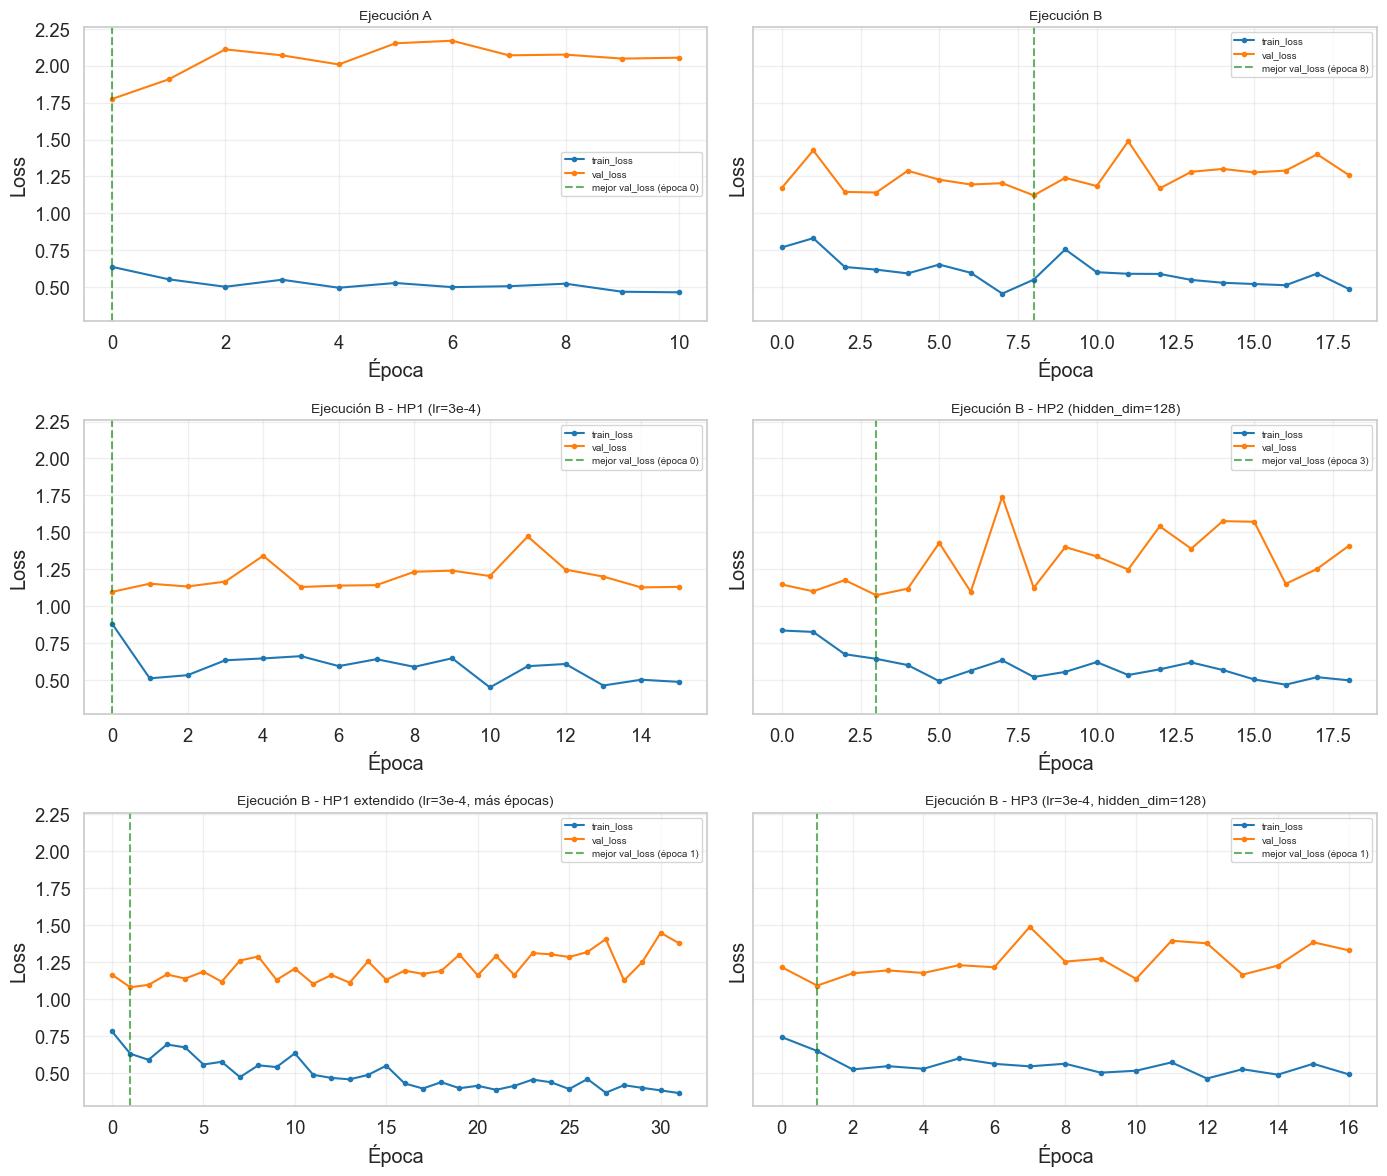

In [57]:
configs_logs = [
    (resultado.nombre_config, "lightning_logs"),
    (resultado_b.nombre_config, "lightning_logs_b"),
    (resultado_hp1.nombre_config, "lightning_logs_b_hp1"),
    (resultado_hp2.nombre_config, "lightning_logs_b_hp2"),
    (resultado_hp1_ext.nombre_config, "lightning_logs_b_hp1_ext"),
    (resultado_hp3.nombre_config, "lightning_logs_b_hp3"),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharey=True)

for ax, (nombre, carpeta_logs) in zip(axes.flat, configs_logs):
    version_dirs = sorted(glob.glob(f"{carpeta_logs}/version_*"), key=lambda p: int(p.split("_")[-1]))
    metrics = pd.read_csv(f"{version_dirs[-1]}/metrics.csv")
    train_por_epoca = metrics.groupby("epoch")["train_loss"].mean()
    val_por_epoca = metrics.groupby("epoch")["val_loss"].mean()

    ax.plot(train_por_epoca.index, train_por_epoca.values, marker="o", markersize=3, label="train_loss")
    ax.plot(val_por_epoca.index, val_por_epoca.values, marker="o", markersize=3, label="val_loss")
    ax.axvline(val_por_epoca.idxmin(), color="green", linestyle="--", alpha=0.6, label=f"mejor val_loss (época {val_por_epoca.idxmin()})")
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



### 8.2 Comparación contra el criterio de aceptación del TP

El paper de Rahmanifard y Gates (2024) revisa 95 estudios. El 65% tiene un MAPE < 20%, y el 80% tiene un R² > 0,6. La propuesta del TP toma esos dos valores como criterio de aceptación. Dentro de los 95 estudios analizados, se distinguen dos grupos según el tipo de datos procesados: 81% de los estudios usa datos de campo, 19% datos sintéticos. El desempeño difiere mucho entre estos dos grupos:

| | Datos de campo (81%) | Datos sintéticos (19%) |
|---|---|---|
| MAPE | 0,4% a 86% | 0% a 22% |
| R² | 0,2 a 0,99 | 0,54 a 1 |

A continuación se describen los resultados del TP, comparados con el criterio de aceptación y con el rango de datos de campo del paper:

- Ninguna configuración se acerca al criterio del TP (MAPE < 20%, R² > 0,6).
- En val, el MAPE robusto va de 133,92% (HP3) a 163,73% (Ejecución A) -- muy por encima del techo de 86% que el paper reporta para datos de campo -- y el R² de 0,0364 (HP2) a 0,1718 (HP1 extendido), por debajo del piso de 0,2 del paper.
- En test, HP1 extendido mejora algo (MAPE robusto=113,51%, R²=0,2555): el MAPE sigue muy por encima del techo de 86%, pero el R² sí entra dentro del rango reportado para datos de campo, aunque cerca del extremo inferior. Es un solo resultado, con una sola inicialización de pesos: no alcanza para sacar conclusiones. Habría que repetir el entrenamiento de HP1 extendido con otras semillas para confirmar que la mejora sobre test se sostiene y no es ruido de esa corrida en particular.

El paper también reconoce dos limitaciones propias del campo: la calidad/cantidad de datos, y la necesidad de un dataset que refleje la naturaleza dinámica del pozo en el tiempo. Es la misma limitación que describimos con más detalle en las Conclusiones que siguen a continuación.

**Otro punto a tener en cuenta: el horizonte que predice cada estudio.**

- Este TP predice una secuencia de 12 valores mensuales (t+1 a t+12).
- Varios de los 95 estudios citados predicen, en cambio, un solo valor acumulado a un horizonte fijo. Por ejemplo: Wang and Chen (2016) y Wang et al. (2019), a 6 y 18 meses en Bakken; Schuetter et al. (2015, 2018), a 12 meses en Wolfcamp.
- Acertar un acumulado es más simple que acertar la secuencia completa: alcanza con el total, no con la forma mes a mes. Un modelo autoregresivo, además, puede acumular error a lo largo del horizonte.
- El paper no desagrega sus rangos por este criterio. No se puede cuantificar cuánto explica esta diferencia, pero es otro motivo para no tomar el 20%/0,6 como techo directamente comparable.


### 8.3 Conclusiones


- **Los resultados quedan lejos del criterio de aceptación del TP**: el MAPE robusto (113,51% a 163,73% según la configuración) supera el techo de 86% que el paper reporta para datos de campo. El R² en val (0,0364 a 0,1718) queda por debajo del piso de 0,2 del paper; en test (0,2555) entra dentro del rango de datos de campo (0,2 a 0,99). Además, este TP predice una secuencia mensual completa, no un acumulado a un horizonte fijo como varios de los estudios citados -- una tarea más exigente, que el paper no refleja en estos rangos (ver comparación completa en 8.2).

- **Reactivaciones y saltos de producción: un límite de los datos**: en varios pozos se observan saltos abruptos que la predicción no anticipa, probablemente por intervenciones operativas (re-fracturas, cambio de equipo de levantamiento).
  - Dentro de la mejor configuración (HP1 extendido): el MAPE robusto es de 8,5%-23,9% en las 6 mejores predicciones (trayectorias estables o en declive suave, sin cambio de régimen en la ventana), contra 419%-2013% en las 6 peores (producción cae a niveles casi nulos *dentro* de la ventana, varias marcadas como parada real según `tipoestado`).
  - Ninguna intervención se informa en el dataset, que solo incluye parámetros de la completación original -- un modelo que solo ve historia de producción no tiene forma de anticiparlas.
  - El estudio [Changing the Equation on Refracturing Shale Oil Wells](https://jpt.spe.org/twa/changing-equation-refracturing-shale-oil-wells) (38 pozos re-fracturados) reportó recuperación incremental en todos los casos, en promedio 92% y 74% de la producción inicial (JPT/SPE).

- **La Ejecución B tiene un MAPE robusto y R² apenas mejores que la Ejecución A** (MAPE 145,52% vs. 163,73%; R²=0,0611 vs. 0,0367): la dirección es consistente con que las paradas explican parte del mal desempeño, pero la diferencia es chica. La evidencia más clara está en el punto anterior.


- **Ajuste de hiperparámetros mejora los números, pero no acerca al criterio del TP**: sobre la Ejecución B se probaron 4 variaciones: learning rate más chico (HP1), `hidden_dim` más grande (HP2), HP1 extendido con más épocas de entrenamiento, y la combinación de ambos cambios (HP3). El mejor R² (0,1718, HP1 extendido) y el mejor MAPE robusto (133,92%, HP3) mejoran sobre el baseline de B, pero siguen lejos del criterio del TP. Como se vio en 8.1, esto sugiere que la inicialización de pesos pesa más en el resultado que estas diferencias de hiperparámetros.

## 9. Ideas para el trabajo final de la maestría

De cara al trabajo final de la maestría, estas son las líneas que surgieron de este TP:

1. **Incorporar regresores para explicar reactivaciones y saltos de producción**: como se observó en las conclusiones, hay saltos que el modelo no puede anticipar, seguramente debidos a re-fracturas y otros tipos de intervenciones. Entonces, podría evaluarse incorporar datos propietarios de intervenciones (`y_regressors` ya soporta regresores futuros), aunque en este caso el modelo dejaría de usar solamente datos de carácter público como se planteó en el anteproyecto. Conocer el campo `tipoestado` en el futuro implicaría acceder a datos de planificación de paradas, que son de carácter propietario. También podrían incorporarse proxies de tipo público, como el precio del petróleo.

2. **Explorar distintas granularidades de predicción**: desglosar el error por mes del horizonte (t+1 a t+12) permitiría analizar si el error crece con la distancia de predicción. Esto motivaría evaluar si predecir con mayor granularidad (ej. semestre, año completo) produce mejores resultados que la secuencia mensual completa. Un acumulado a 12 meses también daría un punto de comparación más directo contra la literatura que predice de esa forma, en vez de una secuencia mes a mes (ver 8.2). **Nota**: esto implicaría reformular aspectos del anteproyecto, como el Objetivo Específico 2, que hoy plantea la predicción de "la curva... en el horizonte de 12 meses (t+1 a t+12)".

3. **MAPE promediado por pozo, como métrica complementaria**: `evaluar_mape_r2` ya reporta el MAPE pooleado (todos los pozo-mes concatenados). Calcular además el MAPE robusto por pozo, y promediarlo entre pozos, daría una vista complementaria: permitiría analizar si el mal desempeño está generalizado entre los pozos o concentrado en ciertos tipos (por producción, cantidad de paradas, etc.), en vez de un único número agregado. El paper de referencia no aclara con qué nivel de agregación se calculó el MAPE en cada uno de los 95 estudios revisados — no hay una definición única al respecto en la literatura

4. **Criterio de elegibilidad de paradas — distinguir declinación terminal de paradas recuperables**: el filtro actual descarta pozos con muchos meses de producción casi nula (`prod_pet <= 1`), pero podría no distinguir una parada transitoria de una declinación terminal, donde el pozo se acerca a su fin económico y no tendría sentido generar predicciones.

5. **Evaluar generalización a pozos no vistos** (`val_unseen`/`test_unseen`) — la infraestructura ya está construida en `PozoDataModule`, pero no se usó en este análisis. La varianza entre corridas, por efecto de la inicialización, tiene un peso importante en este TP. Por eso, una comparación seen/unseen con una sola corrida no sería confiable. Convendría repetirla con varias semillas, o directamente evaluarla con otro modelo, ya que no parece justificado invertir más trabajo en este modelo en particular.

6. **Probar PatchTST, un Transformer específico para series temporales** (Nie et al., 2023, ya citado en el anteproyecto): agrupa la serie en "parches" de varios meses en vez de un token por mes, de forma que cada token resume la forma de un tramo de entrada en vez de un valor mensual aislado. El patching es solo del input -- la implementación de referencia (y las más usadas, como la de Hugging Face) proyectan la salida directo al horizonte completo con una capa lineal, sin agrupar. Por eso, por sí sola no resolvería el problema de los cambios de régimen dentro de la ventana: esa mejora requeriría además cambiar la granularidad de salida (idea 2).